# 99_analyze_ann_full — Black-Litterman LSTM vs ANN 분석 (2010-2025 전체)

본 노트북은 `final_pt/results/*.pkl` 백테스트 결과를 분석 (full period).

## 구조

```
[L14] SET 1~4 통합 paired (전체 기간, 14 pair)
[L15] SET 1~4 × 4 레짐 paired (56 pair)
[L16] SET 5 — P×Q matrix (P=eq/rp × 6 q, 12 pair)
[L17] Portfolio - mcap prior L1 거리
[L18] Q 값 시계열 / 분포 by 레짐
[L20] prior × q matrix — p_w ∈ {mcap, eq, rp} (각 18 pair)
[L_crisis] 위기 구간 LSTM vs ANN 예측 quality (RMSE/Spearman/Hit)
[L_synthesis] 4단 사슬 narrative — Anchor pair 레짐별 분해
[L_hit] Regime 별 Hit Rate + Anchor BL Sharpe
```

**Anchor** (Pyo & Lee 2018 spec): `mat_mcap_mcap_fpm_pap` (prior=mcap, p_w=mcap, q=fpm, Ω=pap)

**평가 컷오프**: 2025-12-31 (hold-out 미사용, 전체 기간 활용)

**레짐 정의**:
- R1_회복 (2010-01 ~ 2012-06, 30mo): GFC 회복기
- R2_확장 (2012-07 ~ 2019-12, 90mo): 평시 확장기
- R3_위기 (2020-01 ~ 2023-06, 42mo): COVID + 22 베어 + 23 AI 도입기
- R4_정상화 (2023-07 ~ 2025-12, 30mo): rate-cut 시작 + AI 호황


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, platform, math
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'NanumGothic', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR    = Path.cwd()
RESULTS_DIR = BASE_DIR / 'results'
DATA_DIR    = BASE_DIR / 'data'
OUT_DIR     = BASE_DIR / 'outputs' / '99_analyze_ann_full'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = '2025-12-31'

# ── pkl 로드 ────────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    try:
        with open(pkl, 'rb') as f:
            loaded[pkl.stem] = pickle.load(f)
    except Exception as e:
        print(f'  pkl 로드 실패 {pkl.name}: {e}')
n_l = sum(1 for n in loaded if not n.endswith('_ann'))
n_a = sum(1 for n in loaded if n.endswith('_ann'))
print(f'pkl 로드: {len(loaded)}  (LSTM {n_l} / ANN {n_a})')

# ── rf + spy (monthly_panel 에서 직접) ──────────────────────────
_panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                     usecols=['date','ticker','rf_1m','spy_ret'], parse_dates=['date'])
rf      = _panel.groupby('date')['rf_1m'].first().dropna()
spy_ret = _panel.groupby('date')['spy_ret'].first().dropna()
print(f'rf/spy 기간: {rf.index[0].date()} ~ {rf.index[-1].date()}')


pkl 로드: 216  (LSTM 108 / ANN 108)
rf/spy 기간: 2005-01-31 ~ 2025-12-31


## L14. SET 1~4 통합 paired (전체 기간)

**Anchor**: `mat_mcap_mcap_fpm_pap` (★)

- **SET 1 (Q only)**: prior=mcap, p_w=mcap 고정 → q 6종 (6 pair)
- **SET 2 (P only)**: prior=mcap, q=fpm 고정 → p_w {mcap, eq, rp} (3 pair)
- **SET 3 (Prior only)**: p_w=mcap, q=fpm 고정 → prior {mcap, eq, rp} (3 pair)
- **SET 4 (Omega only)**: prior=mcap, p_w=mcap, q=fpm 고정 → omega {pap, he} (2 pair)

총 14 paired. 평가 기간 = 2010-01 ~ 2023-12 (hold-out 제외).


In [2]:
# ── L14. SET 1~4 통합 paired (전체 기간) ──
def _full_metrics(ret, rf_s, mkt_s):
    r = ret.dropna()
    r = r[r.index <= CUTOFF]
    if len(r) < 12:
        return None
    rfa = rf_s.reindex(r.index).fillna(0); mka = mkt_s.reindex(r.index).fillna(0)
    exc = r - rfa; mexc = mka - rfa
    vol = r.std() * np.sqrt(12)
    cagr = (1 + r).prod() ** (12 / len(r)) - 1
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = r[r < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    if mexc.var() > 0:
        beta  = float(np.cov(exc, mexc, ddof=0)[0,1] / mexc.var())
        alpha = float((exc.mean() - beta * mexc.mean()) * 12)
    else:
        beta = alpha = np.nan
    return dict(Sharpe=sh, Sortino=so, CAGR=cagr, Vol=vol, MDD=mdd, Beta=beta, Alpha=alpha)


def _get(name):
    if name not in loaded: return None
    ret = loaded[name].get('ret')
    if not isinstance(ret, pd.Series): return None
    return _full_metrics(ret, rf, spy_ret)


# Anchor 별칭
ANCHOR_L = 'mat_mcap_mcap_fpm_pap'
ANCHOR_A = 'mat_mcap_mcap_fpm_pap_ann'

SETS = {
    'SET 1: Q only (prior=mcap, p_w=mcap)': [
        ('q=fix',     'mat_mcap_mcap_fix_pap', 'mat_mcap_mcap_fix_pap_ann'),
        ('q=lam',     'mat_mcap_mcap_lam_pap', 'mat_mcap_mcap_lam_pap_ann'),
        ('q=raw',     'mat_mcap_mcap_raw_pap', 'mat_mcap_mcap_raw_pap_ann'),
        ('q=inv',     'mat_mcap_mcap_inv_pap', 'mat_mcap_mcap_inv_pap_ann'),
        ('q=vsp',     'mat_mcap_mcap_vsp_pap', 'mat_mcap_mcap_vsp_pap_ann'),
        ('q=fpm ★',  ANCHOR_L,                ANCHOR_A),
    ],
    'SET 2: P only (prior=mcap, q=fpm)': [
        ('p_w=mcap ★', ANCHOR_L,              ANCHOR_A),
        ('p_w=eq',     'mat_mcap_eq_fpm_pap', 'mat_mcap_eq_fpm_pap_ann'),
        ('p_w=rp',     'mat_mcap_rp_fpm_pap', 'mat_mcap_rp_fpm_pap_ann'),
    ],
    'SET 3: Prior only (p_w=mcap, q=fpm)': [
        ('prior=mcap ★', ANCHOR_L,              ANCHOR_A),
        ('prior=eq',     'mat_eq_mcap_fpm_pap', 'mat_eq_mcap_fpm_pap_ann'),
        ('prior=rp',     'mat_rp_mcap_fpm_pap', 'mat_rp_mcap_fpm_pap_ann'),
    ],
    'SET 4: Omega only (prior=mcap, p_w=mcap, q=fpm)': [
        ('omega=pap ★', ANCHOR_L,               ANCHOR_A),
        ('omega=he',    'mat_mcap_mcap_fpm_he', 'mat_mcap_mcap_fpm_he_ann'),
    ],
}

all_rows = []
for set_name, pairs in SETS.items():
    for label, lname, aname in pairs:
        L = _get(lname); A = _get(aname)
        if not L or not A:
            print(f'  missing: {lname} or {aname}')
            continue
        all_rows.append({
            'SET': set_name.split(':')[0],
            'config': label,
            'L_Sharpe': L['Sharpe'], 'A_Sharpe': A['Sharpe'], 'd_Sharpe': L['Sharpe']-A['Sharpe'],
            'L_Sortino': L['Sortino'], 'A_Sortino': A['Sortino'], 'd_Sortino': L['Sortino']-A['Sortino'],
            'L_CAGR': L['CAGR'], 'A_CAGR': A['CAGR'], 'd_CAGR': L['CAGR']-A['CAGR'],
            'L_Alpha': L['Alpha'], 'A_Alpha': A['Alpha'], 'd_Alpha': L['Alpha']-A['Alpha'],
            'L_MDD': L['MDD'], 'A_MDD': A['MDD'], 'd_MDD': L['MDD']-A['MDD'],
            'win': 'LSTM' if L['Sharpe'] > A['Sharpe'] else 'ANN',
        })

cmp_df = pd.DataFrame(all_rows)

# SET별 요약
print('='*72)
print('SET별 LSTM 우위 요약 (paper-faithful anchor)')
print('='*72)
for set_id in cmp_df['SET'].unique():
    sub = cmp_df[cmp_df['SET'] == set_id]
    n = len(sub)
    wL = (sub['win'] == 'LSTM').sum()
    p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
    print(f'[{set_id}] n={n}, LSTM win={wL}/{n}, p={p_val:.3f}')
    print(f'   mean d_Sharpe  = {sub["d_Sharpe"].mean():+.4f}')
    print(f'   mean d_Sortino = {sub["d_Sortino"].mean():+.4f}')
    print(f'   mean d_CAGR    = {sub["d_CAGR"].mean():+.2%}')
    print(f'   mean d_Alpha   = {sub["d_Alpha"].mean():+.2%}')
    print(f'   mean d_MDD     = {sub["d_MDD"].mean():+.2%}  (+= LSTM 덜 빠짐)')

n = len(cmp_df); wL = (cmp_df['win'] == 'LSTM').sum()
p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
print()
print('='*72)
print(f'전체 통합 ({n} pair): LSTM win={wL}/{n}, p={p_val:.3f}')
print('='*72)
print()

# 표
def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v):
        return ''
    if v > 0:
        return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0:
        return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

styled = (cmp_df.set_index(['SET','config'])[[
        'L_Sharpe','A_Sharpe','d_Sharpe',
        'L_Sortino','A_Sortino','d_Sortino',
        'L_Alpha','A_Alpha','d_Alpha',
        'L_MDD','A_MDD','d_MDD',
        'win']]
    .style
    .format({
        'L_Sharpe':'{:.3f}','A_Sharpe':'{:.3f}','d_Sharpe':'{:+.3f}',
        'L_Sortino':'{:.3f}','A_Sortino':'{:.3f}','d_Sortino':'{:+.3f}',
        'L_Alpha':'{:.2%}','A_Alpha':'{:.2%}','d_Alpha':'{:+.2%}',
        'L_MDD':'{:.2%}','A_MDD':'{:.2%}','d_MDD':'{:+.2%}',
    })
    .map(_hl_diff, subset=['d_Sharpe','d_Sortino','d_Alpha','d_MDD']))
styled


SET별 LSTM 우위 요약 (paper-faithful anchor)
[SET 1] n=6, LSTM win=4/6, p=0.344
   mean d_Sharpe  = -0.0050
   mean d_Sortino = +0.0226
   mean d_CAGR    = +0.16%
   mean d_Alpha   = +0.15%
   mean d_MDD     = -0.64%  (+= LSTM 덜 빠짐)
[SET 2] n=3, LSTM win=3/3, p=0.125
   mean d_Sharpe  = +0.0449
   mean d_Sortino = +0.0863
   mean d_CAGR    = +1.03%
   mean d_Alpha   = +0.86%
   mean d_MDD     = -0.87%  (+= LSTM 덜 빠짐)
[SET 3] n=3, LSTM win=3/3, p=0.125
   mean d_Sharpe  = +0.0068
   mean d_Sortino = -0.0470
   mean d_CAGR    = +1.06%
   mean d_Alpha   = +1.17%
   mean d_MDD     = -5.36%  (+= LSTM 덜 빠짐)
[SET 4] n=2, LSTM win=1/2, p=0.750
   mean d_Sharpe  = -0.0204
   mean d_Sortino = -0.0475
   mean d_CAGR    = +0.80%
   mean d_Alpha   = +1.32%
   mean d_MDD     = -1.51%  (+= LSTM 덜 빠짐)

전체 통합 (14 pair): LSTM win=11/14, p=0.029



## L15. SET 1~4 × 3 레짐 paired

각 SET pair 를 R1_회복 / R2_확장 / R3_위기 / R4_정상화 로 분할 평가. 총 14 pair × 4 레짐 = 56 entry.

**가설**: ANN 의 anchor 우위는 위기 포함 레짐 (R1·R3) 에 집중, calm (R2_확장) 에서는 LSTM 이 슬롯 전반에서 우위.


In [3]:
# ── L15. SET 1~4 × 레짐별 paired ──
# 2010-2025 전체 기간 4-레짐 분해
REGIMES = [
    ('R1_회복',   '2010-01-01', '2012-06-30'),   # 30mo: GFC 회복
    ('R2_확장',   '2012-07-01', '2019-12-31'),   # 90mo: 평시 확장
    ('R3_위기',   '2020-01-01', '2023-06-30'),   # 42mo: COVID + 22 베어 + 23 AI 도입기
    ('R4_정상화', '2023-07-01', '2025-12-31'),   # 30mo: rate-cut 시작 + AI 호황
]

def _regime_metrics(name, s, e):
    if name not in loaded: return None
    r = loaded[name]['ret'].dropna()
    r = r[r.index <= CUTOFF]
    sub = r[(r.index >= s) & (r.index <= e)]
    if len(sub) < 6: return None
    rfa = rf.reindex(sub.index).fillna(0); mka = spy_ret.reindex(sub.index).fillna(0)
    exc = sub - rfa; mexc = mka - rfa
    vol = sub.std() * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = sub[sub < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + sub).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    if mexc.var() > 0:
        beta = float(np.cov(exc, mexc, ddof=0)[0,1] / mexc.var())
        alpha = float((exc.mean() - beta * mexc.mean()) * 12)
    else:
        beta = alpha = np.nan
    return dict(Sharpe=sh, Sortino=so, MDD=mdd, Alpha=alpha)


SETS_L15 = {
    'SET1': SETS['SET 1: Q only (prior=mcap, p_w=mcap)'],
    'SET2': SETS['SET 2: P only (prior=mcap, q=fpm)'],
    'SET3': SETS['SET 3: Prior only (p_w=mcap, q=fpm)'],
    'SET4': SETS['SET 4: Omega only (prior=mcap, p_w=mcap, q=fpm)'],
}

all_rows = []
for set_id, pairs in SETS_L15.items():
    for label, L, A in pairs:
        for lbl, s, e in REGIMES:
            mL = _regime_metrics(L, s, e); mA = _regime_metrics(A, s, e)
            if mL is None or mA is None: continue
            all_rows.append({
                'SET': set_id, 'pair': label, 'regime': lbl,
                'L_Sh': mL['Sharpe'], 'A_Sh': mA['Sharpe'], 'd_Sh': mL['Sharpe']-mA['Sharpe'],
                'L_So': mL['Sortino'], 'A_So': mA['Sortino'], 'd_So': mL['Sortino']-mA['Sortino'],
                'L_MDD': mL['MDD'], 'A_MDD': mA['MDD'],
                'win': 'LSTM' if mL['Sharpe'] > mA['Sharpe'] else 'ANN',
            })

reg_df = pd.DataFrame(all_rows)

# (1) SET × 레짐 LSTM 승수
print('='*78)
print('SET × 레짐 LSTM 승수')
print('='*78)
print(f'{"":<8s}' + ''.join(f'{lbl:>14s}' for lbl,_,_ in REGIMES) + f'{"합계":>10s}')
print('-'*78)
for set_id in ['SET1','SET2','SET3','SET4']:
    sub_set = reg_df[reg_df['SET'] == set_id]
    n_pair = sub_set['pair'].nunique()
    cells = []
    total_w = 0
    for lbl, _, _ in REGIMES:
        sub = sub_set[sub_set['regime'] == lbl]
        wL = (sub['win']=='LSTM').sum()
        cells.append(f'{wL}/{n_pair}')
        total_w += wL
    print(f'{set_id:<8s}' + ''.join(f'{c:>14s}' for c in cells) + f'{total_w}/{n_pair*len(REGIMES):>5d}'.rjust(10))

print('-'*78)
total_per_regime = []
for lbl, _, _ in REGIMES:
    sub = reg_df[reg_df['regime'] == lbl]
    wL = (sub['win']=='LSTM').sum()
    total_per_regime.append(f'{wL}/{len(sub)}')
print(f'{"합계":<8s}' + ''.join(f'{c:>14s}' for c in total_per_regime) +
      f'{(reg_df["win"]=="LSTM").sum()}/{len(reg_df):>5d}'.rjust(10))
print('='*78)

# (2) 평균 d_Sharpe / d_Sortino
print()
print('레짐별 평균 LSTM 우위 (Sharpe / Sortino)')
print('-'*60)
for lbl, _, _ in REGIMES:
    for set_id in ['SET1','SET2','SET3','SET4']:
        sub = reg_df[(reg_df['regime']==lbl) & (reg_df['SET']==set_id)]
        if len(sub)==0: continue
        print(f'  [{lbl}] {set_id}: mean d_Sh={sub["d_Sh"].mean():+.3f}, d_So={sub["d_So"].mean():+.3f}')
    print()

# (3) 풀 표
def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

styled = (reg_df.set_index(['SET','pair','regime'])[[
        'L_Sh','A_Sh','d_Sh','L_So','A_So','d_So','L_MDD','A_MDD','win']]
    .style
    .format({
        'L_Sh':'{:.3f}','A_Sh':'{:.3f}','d_Sh':'{:+.3f}',
        'L_So':'{:.3f}','A_So':'{:.3f}','d_So':'{:+.3f}',
        'L_MDD':'{:.2%}','A_MDD':'{:.2%}',
    })
    .map(_hl_diff, subset=['d_Sh','d_So']))
styled


SET × 레짐 LSTM 승수
                 R1_회복         R2_확장         R3_위기        R4_정상화        합계
------------------------------------------------------------------------------
SET1               0/6           2/6           5/6           4/6  11/   24
SET2               0/3           3/3           2/3           3/3   8/   12
SET3               0/3           3/3           0/3           3/3   6/   12
SET4               0/2           2/2           0/2           1/2   3/    8
------------------------------------------------------------------------------
합계                0/14         10/14          7/14         11/14  28/   56

레짐별 평균 LSTM 우위 (Sharpe / Sortino)
------------------------------------------------------------
  [R1_회복] SET1: mean d_Sh=-0.229, d_So=-0.248
  [R1_회복] SET2: mean d_Sh=-0.159, d_So=-0.077
  [R1_회복] SET3: mean d_Sh=-0.283, d_So=-0.358
  [R1_회복] SET4: mean d_Sh=-0.286, d_So=-0.360

  [R2_확장] SET1: mean d_Sh=-0.054, d_So=-0.131
  [R2_확장] SET2: mean d_Sh=+0.086, d_So=+0.045
  

## L16. SET 5 — P×Q matrix (P=eq/rp × 6 q)

**고정**: prior=mcap, omega=ff3_paper
**변경**: p_weight ∈ {eq, rp} × q_mode ∈ {fix, lam, raw, inv, vsp, fpm} = 12 pair

P=eq/rp 슬롯의 LSTM 우위가 q_mode 변경에 일관되게 유지되는지 확인.


In [4]:
# ── L16. SET 5 P×Q matrix — LSTM vs ANN (전체 + 레짐별, Sharpe + Sortino) ──
def _regime_sh_so(name, s, e):
    if name not in loaded: return None, None
    r = loaded[name]['ret'].dropna()
    r = r[r.index <= CUTOFF]
    sub = r[(r.index >= s) & (r.index <= e)]
    if len(sub) < 6: return None, None
    rfa = rf.reindex(sub.index).fillna(0)
    exc = sub - rfa
    vol = sub.std() * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = sub[sub < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    return sh, so

PAIRS_L16 = []
for pw in ['eq', 'rp']:
    for q in ['fix', 'lam', 'raw', 'inv', 'vsp', 'fpm']:
        L = f'mat_mcap_{pw}_{q}_pap'
        A = f'mat_mcap_{pw}_{q}_pap_ann'
        PAIRS_L16.append((pw, q, f'P={pw} / Q={q}', L, A))

rows = []
for pw, q, label, L, A in PAIRS_L16:
    mL = _get(L); mA = _get(A)
    if not mL or not mA:
        print(f'  missing: {L} or {A}')
        continue
    R_sh = {}; R_so = {}
    for lbl, s, e in REGIMES:
        sL_h, sL_o = _regime_sh_so(L, s, e); sA_h, sA_o = _regime_sh_so(A, s, e)
        R_sh[lbl] = (sL_h - sA_h) if (sL_h is not None and sA_h is not None) else np.nan
        R_so[lbl] = (sL_o - sA_o) if (sL_o is not None and sA_o is not None) else np.nan
    row_data = {
        'pw': pw, 'q': q, 'pair': label,
        'L_Sh': mL['Sharpe'], 'A_Sh': mA['Sharpe'], 'd_Sh': mL['Sharpe']-mA['Sharpe'],
        'd_So': mL['Sortino'] - mA['Sortino'],
        'd_MDD': mL['MDD'] - mA['MDD'],
        'd_Alp': mL['Alpha'] - mA['Alpha'],
        'win': 'LSTM' if mL['Sharpe'] > mA['Sharpe'] else 'ANN',
    }
    for i, (lbl, _, _) in enumerate(REGIMES, 1):
        row_data[f'R{i}_d_Sh'] = R_sh[lbl]
        row_data[f'R{i}_d_So'] = R_so[lbl]
    rows.append(row_data)
df_full = pd.DataFrame(rows)

n = len(df_full); wL = (df_full['win'] == 'LSTM').sum()
p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
print('='*78)
print(f'SET 5 전체 기간: LSTM win={wL}/{n}, p={p_val:.4f}')
print(f'   mean d_Sharpe  = {df_full["d_Sh"].mean():+.4f}')
print(f'   mean d_Sortino = {df_full["d_So"].mean():+.4f}')
print(f'   mean d_Alpha   = {df_full["d_Alp"].mean():+.2%}')
print(f'   mean d_MDD     = {df_full["d_MDD"].mean():+.2%}')
print('='*78)

# 레짐별 승수 + 평균 (Sharpe 와 Sortino 둘 다)
print()
print('레짐별 LSTM 승수 + 평균 (Sharpe / Sortino)')
print(f'{"":<14s}' + ''.join(f'{lbl:>22s}' for lbl,_,_ in REGIMES))
print('-'*(14 + 22*len(REGIMES)))
for metric_lbl, sh_cols, so_cols in [
    ('Sharpe',  [f'R{i+1}_d_Sh' for i in range(len(REGIMES))], None),
    ('Sortino', [f'R{i+1}_d_So' for i in range(len(REGIMES))], None),
]:
    print(f'  [{metric_lbl}]')
    for pw in ['eq', 'rp']:
        sub_pw = df_full[df_full['pw'] == pw]
        cells = []
        for col in sh_cols:
            s_pw_lbl = sub_pw.dropna(subset=[col])
            wL_r = (s_pw_lbl[col] > 0).sum()
            n_r = len(s_pw_lbl)
            mean_d = s_pw_lbl[col].mean()
            cells.append(f'{wL_r}/{n_r}  ({mean_d:+.3f})')
        print(f'  {"P=" + pw:<12s}' + ''.join(f'{c:>22s}' for c in cells))
    cells = []
    for col in sh_cols:
        sub = df_full.dropna(subset=[col])
        wL_r = (sub[col] > 0).sum()
        mean_d = sub[col].mean()
        cells.append(f'{wL_r}/{len(sub)}  ({mean_d:+.3f})')
    print(f'  {"합계":<12s}' + ''.join(f'{c:>22s}' for c in cells))
    print()
print('='*82)

def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

_n_reg = len(REGIMES)
_sh_reg_cols = [f'R{i+1}_d_Sh' for i in range(_n_reg)]
_so_reg_cols = [f'R{i+1}_d_So' for i in range(_n_reg)]
_sh_reg_names = [f'Δ Sh (R{i+1})' for i in range(_n_reg)]
_so_reg_names = [f'Δ So (R{i+1})' for i in range(_n_reg)]

_idx_cols = ['L_Sh','A_Sh','d_Sh'] + _sh_reg_cols + ['d_So'] + _so_reg_cols + ['d_MDD','d_Alp','win']
_new_names = ['LSTM Sh','ANN Sh','Δ Sh (전체)'] + _sh_reg_names + ['Δ So (전체)'] + _so_reg_names + ['Δ MDD (전체)','Δ α (전체)','win']

display_df = df_full.set_index('pair')[_idx_cols]
display_df.columns = _new_names

hl_cols = ['Δ Sh (전체)'] + _sh_reg_names + ['Δ So (전체)'] + _so_reg_names + ['Δ MDD (전체)','Δ α (전체)']
fmt_dict = {'LSTM Sh':'{:.3f}','ANN Sh':'{:.3f}'}
for c in ['Δ Sh (전체)'] + _sh_reg_names + ['Δ So (전체)'] + _so_reg_names:
    fmt_dict[c] = '{:+.3f}'
fmt_dict['Δ MDD (전체)'] = '{:+.2%}'
fmt_dict['Δ α (전체)'] = '{:+.2%}'

styled = (display_df.style
    .format(fmt_dict)
    .map(_hl_diff, subset=hl_cols))
print()
styled


SET 5 전체 기간: LSTM win=12/12, p=0.0002
   mean d_Sharpe  = +0.0839
   mean d_Sortino = +0.1824
   mean d_Alpha   = +0.90%
   mean d_MDD     = +3.12%

레짐별 LSTM 승수 + 평균 (Sharpe / Sortino)
                               R1_회복                 R2_확장                 R3_위기                R4_정상화
------------------------------------------------------------------------------------------------------
  [Sharpe]
  P=eq                 0/6  (-0.054)         1/6  (-0.020)         6/6  (+0.283)         6/6  (+0.094)
  P=rp                 5/6  (+0.053)         3/6  (+0.002)         6/6  (+0.248)         6/6  (+0.110)
  합계                  5/12  (-0.000)        4/12  (-0.009)       12/12  (+0.265)       12/12  (+0.102)

  [Sortino]
  P=eq                 5/6  (+0.038)         1/6  (-0.062)         6/6  (+0.595)         6/6  (+0.109)
  P=rp                 6/6  (+0.417)         4/6  (-0.039)         6/6  (+0.535)         6/6  (+0.184)
  합계                 11/12  (+0.228)        5/12  (-0.050)       12/12

,LSTM Sh,ANN Sh,Δ Sh (전체),Δ Sh (R1),Δ Sh (R2),Δ Sh (R3),Δ Sh (R4),Δ So (전체),Δ So (R1),Δ So (R2),Δ So (R3),Δ So (R4),Δ MDD (전체),Δ α (전체),win
pair,,,,,,,,,,,,,,,
P=eq / Q=fix,1.050,0.979,+0.070,-0.029,-0.035,+0.282,+0.063,+0.139,+0.142,-0.093,+0.613,+0.124,+3.95%,+0.90%,LSTM
P=eq / Q=lam,1.067,0.973,+0.094,-0.045,-0.016,+0.373,+0.059,+0.139,+0.019,-0.153,+0.673,+0.106,+4.13%,+1.07%,LSTM
P=eq / Q=raw,1.060,0.976,+0.084,-0.040,-0.034,+0.370,+0.059,+0.141,+0.025,-0.143,+0.668,+0.106,+4.13%,+0.77%,LSTM
P=eq / Q=inv,1.047,0.988,+0.059,-0.030,-0.010,+0.197,+0.097,+0.152,+0.077,+0.057,+0.491,+0.116,+3.07%,+0.69%,LSTM
P=eq / Q=vsp,1.040,0.963,+0.076,-0.028,-0.040,+0.291,+0.084,+0.177,+0.150,-0.019,+0.665,+0.119,+3.79%,+0.88%,LSTM
P=eq / Q=fpm,1.099,1.049,+0.050,-0.152,+0.013,+0.183,+0.198,+0.075,-0.185,-0.020,+0.460,+0.082,+1.57%,+0.75%,LSTM
P=rp / Q=fix,1.012,0.905,+0.107,+0.057,+0.030,+0.241,+0.117,+0.247,+0.419,+0.009,+0.622,+0.250,+3.25%,+1.16%,LSTM
P=rp / Q=lam,1.042,0.940,+0.101,+0.021,-0.010,+0.333,+0.061,+0.211,+0.353,-0.145,+0.577,+0.157,+4.61%,+0.97%,LSTM
P=rp / Q=raw,1.036,0.956,+0.080,+0.031,-0.060,+0.329,+0.061,+0.198,+0.366,-0.197,+0.573,+0.157,+4.61%,+0.50%,LSTM


## L17. Portfolio - mcap prior L1 거리

**가설**: ANN 의 Sortino 우위는 ANN portfolio 가 mcap prior 에 더 가깝게 (보수적) 머무름 → downside 방어.

**측정**: 매월 ‖w_t - w_t^{mcap_prior}‖_1


                     LSTM 거리        ANN 거리       차이(L-A)        prior 추종
config                  (평균)          (평균)                          강한 쪽
------------------------------------------------------------------------------------

[paper anchor]
  R1_회복              0.727         0.852        -0.125            LSTM
  R2_확장              0.840         0.808        +0.032             ANN
  R3_위기              0.590         0.692        -0.101            LSTM
  R4_정상화             0.647         0.609        +0.038             ANN
  전체                 0.738         0.758        -0.021            LSTM

[P=eq, Q=fpm]
  R1_회복              0.729         0.828        -0.098            LSTM
  R2_확장              0.833         0.872        -0.040            LSTM
  R3_위기              0.738         0.741        -0.004            LSTM
  R4_정상화             0.566         0.609        -0.043            LSTM
  전체                 0.754         0.796        -0.042            LSTM

[P=rp, Q=fpm]
  R1_회복      

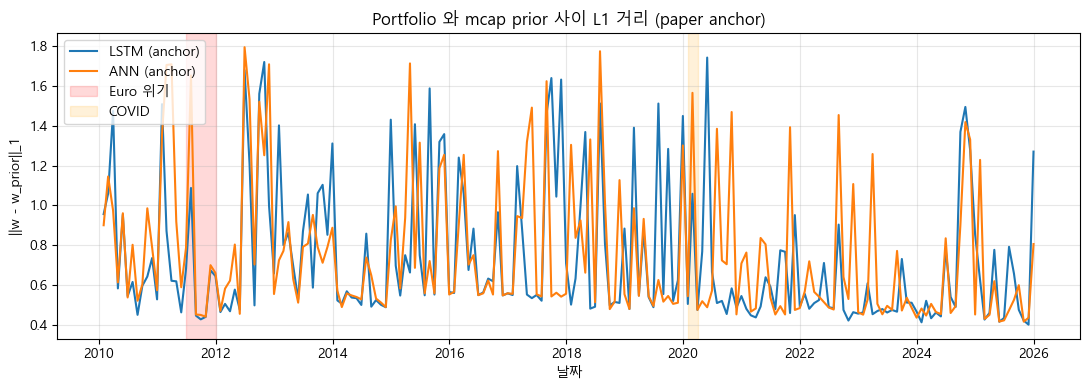

In [5]:
# ── L17. Portfolio - mcap prior L1 거리 ──
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                    usecols=['date','ticker','log_mcap'], parse_dates=['date'])
panel = panel.set_index(['date','ticker'])

mcap_panel  = np.exp(panel['log_mcap']).unstack('ticker')
prior_panel = mcap_panel.div(mcap_panel.sum(axis=1), axis=0)


def _dist_to_prior(name):
    if name not in loaded: return None
    w = loaded[name].get('weights')
    if w is None: return None
    common_dates = w.index.intersection(prior_panel.index)
    common_tix   = w.columns.intersection(prior_panel.columns)
    if len(common_dates) == 0 or len(common_tix) == 0: return None
    w_aligned     = w.loc[common_dates, common_tix].fillna(0)
    prior_aligned = prior_panel.loc[common_dates, common_tix].fillna(0)
    return (w_aligned - prior_aligned).abs().sum(axis=1)


COMPARE = [
    (ANCHOR_L,              ANCHOR_A,                   'paper anchor'),
    ('mat_mcap_eq_fpm_pap', 'mat_mcap_eq_fpm_pap_ann',  'P=eq, Q=fpm'),
    ('mat_mcap_rp_fpm_pap', 'mat_mcap_rp_fpm_pap_ann',  'P=rp, Q=fpm'),
]

print('='*84)
print(f'{"":<14}{"LSTM 거리":>14s}{"ANN 거리":>14s}{"차이(L-A)":>14s}{"prior 추종":>16s}')
print(f'{"config":<14}{"(평균)":>14s}{"(평균)":>14s}{"":>14s}{"강한 쪽":>16s}')
print('-' * 84)

for L_name, A_name, label in COMPARE:
    dL = _dist_to_prior(L_name); dA = _dist_to_prior(A_name)
    if dL is None or dA is None:
        print(f'\n[{label}]  (pkl 없음 또는 weights 없음)')
        continue
    print(f'\n[{label}]')
    for lbl, s, e in REGIMES:
        sub_L = dL[(dL.index >= s) & (dL.index <= e)]
        sub_A = dA[(dA.index >= s) & (dA.index <= e)]
        diff = sub_L.mean() - sub_A.mean()
        winner = 'ANN' if diff > 0 else 'LSTM'
        print(f'  {lbl:<10}  {sub_L.mean():>12.3f}  {sub_A.mean():>12.3f}  {diff:>+12.3f}  {winner:>14s}')
    print(f'  {"전체":<10}  {dL.mean():>12.3f}  {dA.mean():>12.3f}  {dL.mean()-dA.mean():>+12.3f}  '
          f'{"ANN" if dL.mean()>dA.mean() else "LSTM":>14s}')

print()
fig, ax = plt.subplots(figsize=(11, 4))
dL = _dist_to_prior(ANCHOR_L)
dA = _dist_to_prior(ANCHOR_A)
if dL is not None and dA is not None:
    ax.plot(dL.index, dL.values, label='LSTM (anchor)', color='C0', lw=1.5)
    ax.plot(dA.index, dA.values, label='ANN (anchor)',  color='C1', lw=1.5)
    ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red', label='Euro 위기')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange', label='COVID')
    ax.set_title('Portfolio 와 mcap prior 사이 L1 거리 (paper anchor)')
    ax.set_ylabel('||w - w_prior||_1')
    ax.set_xlabel('날짜')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## L18. Q 값 시계열 / 분포 by 레짐

**검증**: LSTM Q 가 ANN Q 보다 음수 더 많거나 절대값이 크면 → low-vol 알파 안 잡힐 때 strong negative bet → R1·R3 손실 큼.

각 pkl `meta['Q']` 컬럼 사용.


레짐                      평균 Q        표준편차       음수 비율      |Q| 평균
--------------------------------------------------------------------------------

[R1_회복]
  LSTM          +0.00012     0.00204       43.3%     0.00159
  ANN           +0.00222     0.00130        3.3%     0.00227

[R2_확장]
  LSTM          -0.00105     0.00366       61.1%     0.00290
  ANN           -0.00011     0.00292       44.4%     0.00222

[R3_위기]
  LSTM          -0.00091     0.00373       69.0%     0.00297
  ANN           -0.00003     0.00334       40.5%     0.00254

[R4_정상화]
  LSTM          -0.01003     0.00809       80.0%     0.01111
  ANN           -0.00987     0.00678       90.0%     0.01000

[전체]
  LSTM          -0.00224     0.00559       63.0%     0.00399
  ANN           -0.00125     0.00530       44.3%     0.00351


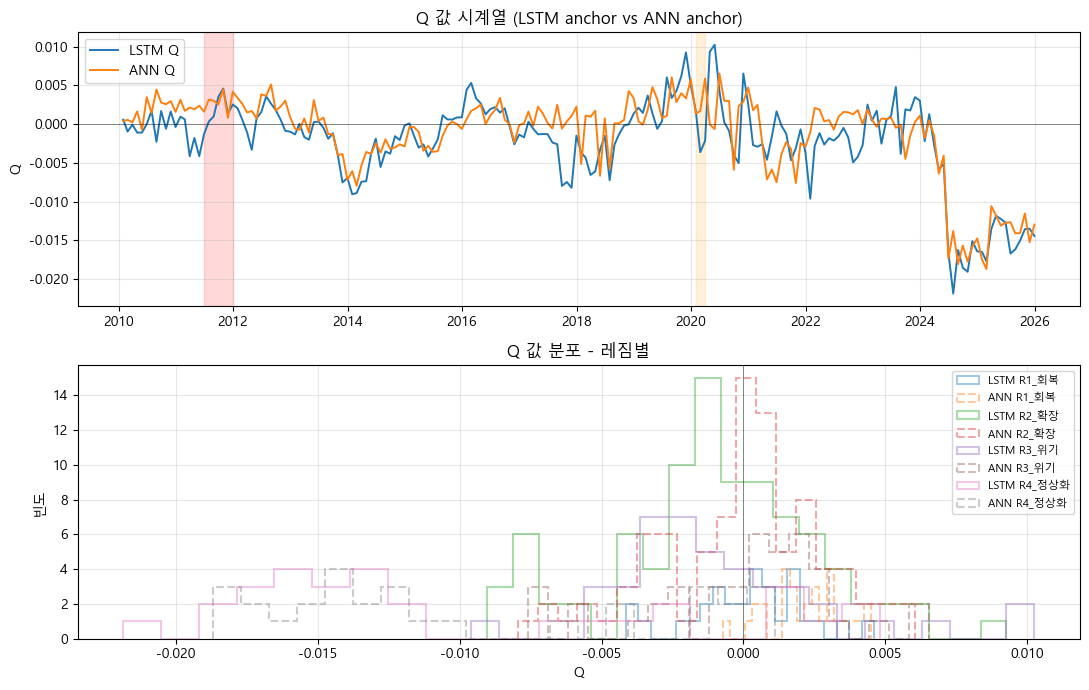


가중치 구성 분석 (anchor portfolio)

레짐                     저변동       고변동       L-H      활성     N_eff
  (low/high-vol = vol_21d 하위/상위 30%, L-H = low-high spread, BL Q 의 부호와 직접 연관)
--------------------------------------------------------------------------------

[R1_회복]
  LSTM          55.80%     8.76%   +47.05%     151      58.3
  ANN           59.95%     8.23%   +51.72%     135      58.3
  Δ(L-A)         -4.1%p    +0.5%p

[R2_확장]
  LSTM          43.25%    20.63%   +22.62%     178     105.5
  ANN           45.48%    18.29%   +27.19%     172     101.7
  Δ(L-A)         -2.2%p    +2.3%p

[R3_위기]
  LSTM          40.40%    21.35%   +19.05%     194      91.1
  ANN           42.16%    19.87%   +22.29%     176      82.5
  Δ(L-A)         -1.8%p    +1.5%p

[R4_정상화]
  LSTM          25.07%    39.66%   -14.59%     169      46.1
  ANN           26.36%    36.76%   -10.40%     171      48.7
  Δ(L-A)         -1.3%p    +2.9%p

[전체]
  LSTM          41.75%    21.91%   +19.84%     176      85.7
  ANN           4

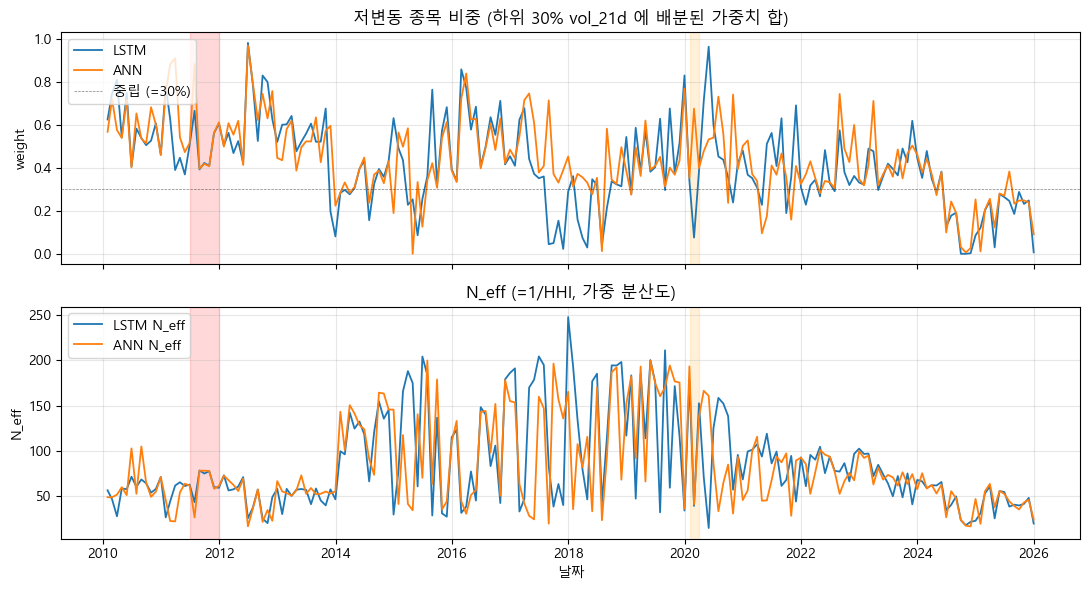

In [6]:
# ── L18. Q 시계열 + 레짐별 분포 (paper anchor) ──
def _get_Q(name):
    if name not in loaded: return None
    meta = loaded[name].get('meta', {})
    return meta.get('Q')

QL = _get_Q(ANCHOR_L)
QA = _get_Q(ANCHOR_A)

if QL is None or QA is None:
    print('Q 데이터 없음 — anchor pkl 의 meta[Q] 확인 필요')
else:
    print('=' * 80)
    print(f'{"레짐":<10s}{"":<6s}{"평균 Q":>12s}{"표준편차":>12s}{"음수 비율":>12s}{"|Q| 평균":>12s}')
    print('-' * 80)
    for lbl, s, e in REGIMES:
        qL = QL[(QL.index >= s) & (QL.index <= e)]
        qA = QA[(QA.index >= s) & (QA.index <= e)]
        print(f'\n[{lbl}]')
        print(f'  {"LSTM":<10s}  {qL.mean():>+10.5f}  {qL.std():>10.5f}  {(qL<0).mean():>10.1%}  {qL.abs().mean():>10.5f}')
        print(f'  {"ANN":<10s}  {qA.mean():>+10.5f}  {qA.std():>10.5f}  {(qA<0).mean():>10.1%}  {qA.abs().mean():>10.5f}')

    print()
    print(f'[전체]')
    print(f'  {"LSTM":<10s}  {QL.mean():>+10.5f}  {QL.std():>10.5f}  {(QL<0).mean():>10.1%}  {QL.abs().mean():>10.5f}')
    print(f'  {"ANN":<10s}  {QA.mean():>+10.5f}  {QA.std():>10.5f}  {(QA<0).mean():>10.1%}  {QA.abs().mean():>10.5f}')
    print('=' * 80)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

    ax = axes[0]
    ax.plot(QL.index, QL.values, label='LSTM Q', color='C0', lw=1.4)
    ax.plot(QA.index, QA.values, label='ANN Q',  color='C1', lw=1.4)
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange')
    ax.set_title('Q 값 시계열 (LSTM anchor vs ANN anchor)')
    ax.set_ylabel('Q')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for lbl, s, e in REGIMES:
        qL = QL[(QL.index >= s) & (QL.index <= e)]
        qA = QA[(QA.index >= s) & (QA.index <= e)]
        ax.hist(qL.values, bins=20, alpha=0.4, label=f'LSTM {lbl}', histtype='step', lw=1.5)
        ax.hist(qA.values, bins=20, alpha=0.4, label=f'ANN {lbl}',  histtype='step', lw=1.5, ls='--')
    ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    ax.set_title('Q 값 분포 - 레짐별')
    ax.set_xlabel('Q'); ax.set_ylabel('빈도')
    ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── 가중치 구성 분석 — 저변동 비중 + 보유 종목 수 ──
print()
print('=' * 80)
print('가중치 구성 분석 (anchor portfolio)')
print('=' * 80)

vol_panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                        usecols=['date','ticker','vol_21d'],
                        parse_dates=['date']).set_index(['date','ticker'])
vol_pivot = vol_panel['vol_21d'].unstack('ticker')


def _composition_stats(name, low_pct=0.30, high_pct=0.30, w_thresh=0.001):
    """매월: low-vol/high-vol 비중 (하위/상위 30%), 활성 종목, N_eff.

    BL 의 P matrix 가 low-vol vs high-vol spread bet 이므로 두 비중 모두 핵심.
    Q > 0 → low-vol overweight, Q < 0 → high-vol overweight.
    """
    if name not in loaded: return None
    w = loaded[name].get('weights')
    if w is None: return None
    rows = []
    for dt in w.index:
        if dt > pd.Timestamp(CUTOFF): break
        wt = w.loc[dt].dropna()
        if len(wt) == 0: continue
        vt = vol_pivot.loc[dt].reindex(wt.index).dropna() if dt in vol_pivot.index else None
        if vt is not None and len(vt) > 10:
            lo_cut = vt.quantile(low_pct)
            hi_cut = vt.quantile(1 - high_pct)
            lv_weight = wt.reindex(vt[vt <= lo_cut].index).fillna(0).sum()
            hv_weight = wt.reindex(vt[vt >= hi_cut].index).fillna(0).sum()
        else:
            lv_weight = hv_weight = np.nan
        active_n = int((wt.abs() > w_thresh).sum())
        ww = wt.values
        n_eff = float(1.0 / (ww**2).sum()) if (ww**2).sum() > 0 else np.nan
        rows.append({'date': dt, 'lv_weight': lv_weight, 'hv_weight': hv_weight,
                     'active_n': active_n, 'n_eff': n_eff})
    return pd.DataFrame(rows).set_index('date')


cL = _composition_stats(ANCHOR_L)
cA = _composition_stats(ANCHOR_A)

if cL is None or cA is None:
    print('weights 데이터 없음 — anchor pkl 의 weights 확인 필요')
else:
    print(f'\n{"레짐":<10s}{"":<6s}{"저변동":>10s}{"고변동":>10s}{"L-H":>10s}{"활성":>8s}{"N_eff":>10s}')
    print('  (low/high-vol = vol_21d 하위/상위 30%, L-H = low-high spread, BL Q 의 부호와 직접 연관)')
    print('-' * 80)
    for lbl, s, e in REGIMES:
        lvL = cL.loc[s:e, 'lv_weight'].mean(); lvA = cA.loc[s:e, 'lv_weight'].mean()
        hvL = cL.loc[s:e, 'hv_weight'].mean(); hvA = cA.loc[s:e, 'hv_weight'].mean()
        anL = cL.loc[s:e, 'active_n'].mean();  anA = cA.loc[s:e, 'active_n'].mean()
        neL = cL.loc[s:e, 'n_eff'].mean();     neA = cA.loc[s:e, 'n_eff'].mean()
        print(f'\n[{lbl}]')
        print(f'  {"LSTM":<10s}  {lvL:>8.2%}  {hvL:>8.2%}  {lvL-hvL:>+8.2%}  {anL:>6.0f}  {neL:>8.1f}')
        print(f'  {"ANN":<10s}  {lvA:>8.2%}  {hvA:>8.2%}  {lvA-hvA:>+8.2%}  {anA:>6.0f}  {neA:>8.1f}')
        print(f'  {"Δ(L-A)":<10s}  {(lvL-lvA)*100:>+7.1f}%p {(hvL-hvA)*100:>+7.1f}%p')

    print()
    print(f'[전체]')
    print(f'  {"LSTM":<10s}  {cL["lv_weight"].mean():>8.2%}  {cL["hv_weight"].mean():>8.2%}  {cL["lv_weight"].mean()-cL["hv_weight"].mean():>+8.2%}  {cL["active_n"].mean():>6.0f}  {cL["n_eff"].mean():>8.1f}')
    print(f'  {"ANN":<10s}  {cA["lv_weight"].mean():>8.2%}  {cA["hv_weight"].mean():>8.2%}  {cA["lv_weight"].mean()-cA["hv_weight"].mean():>+8.2%}  {cA["active_n"].mean():>6.0f}  {cA["n_eff"].mean():>8.1f}')
    print('=' * 80)

    # 시계열 plot — 저변동 비중 + N_eff
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax = axes[0]
    ax.plot(cL.index, cL['lv_weight'].values, label='LSTM', color='C0', lw=1.3)
    ax.plot(cA.index, cA['lv_weight'].values, label='ANN',  color='C1', lw=1.3)
    ax.axhline(0.30, color='k', ls='--', lw=0.5, alpha=0.5, label='중립 (=30%)')
    ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange')
    ax.set_title('저변동 종목 비중 (하위 30% vol_21d 에 배분된 가중치 합)')
    ax.set_ylabel('weight'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(cL.index, cL['n_eff'].values, label='LSTM N_eff', color='C0', lw=1.3)
    ax.plot(cA.index, cA['n_eff'].values, label='ANN N_eff',  color='C1', lw=1.3)
    ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange')
    ax.set_title('N_eff (=1/HHI, 가중 분산도)')
    ax.set_ylabel('N_eff'); ax.set_xlabel('날짜')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## L20. prior × q matrix — p_w=eq & p_w=rp (LSTM vs ANN)

**고정**: omega=ff3_paper
**변경**: p_weight ∈ {eq, rp} × prior ∈ {mcap, eq, rp} × q ∈ {fix, lam, raw, inv, vsp, fpm} = 36 pair (18 × 2)

각 p_w 별로 prior × q matrix 표 1개씩 출력.


In [7]:
# ── L20. prior × q matrix for p_w=eq 와 p_w=rp ──
from IPython.display import display, Markdown

def _sh(name, s=None, e=None):
    if name not in loaded: return None
    r = loaded[name]['ret'].dropna()
    r = r[r.index <= CUTOFF]
    if s is not None:
        r = r[(r.index >= s) & (r.index <= e)]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    return float(exc.mean() * 12 / vol) if vol > 0 else np.nan

def _so(name, s=None, e=None):
    if name not in loaded: return None
    r = loaded[name]['ret'].dropna()
    r = r[r.index <= CUTOFF]
    if s is not None:
        r = r[(r.index >= s) & (r.index <= e)]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    dn = r[r < 0].std() * np.sqrt(12)
    return float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan

def _mdd(name, s=None, e=None):
    if name not in loaded: return None
    r = loaded[name]['ret'].dropna()
    r = r[r.index <= CUTOFF]
    if s is not None:
        r = r[(r.index >= s) & (r.index <= e)]
    if len(r) < 6: return None
    cum = (1 + r).cumprod()
    return float((cum / cum.cummax() - 1).min())

def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

def _matrix_for_pw(P_W):
    PAIRS = []
    for pr in ['mcap','eq','rp']:
        for q in ['fix','lam','raw','inv','vsp','fpm']:
            L = f'mat_{pr}_{P_W}_{q}_pap'
            A = f'mat_{pr}_{P_W}_{q}_pap_ann'
            PAIRS.append((pr, q, L, A))

    rows = []
    for pr, q, L, A in PAIRS:
        full_L = _sh(L); full_A = _sh(A)
        if full_L is None or full_A is None:
            row = {'prior': pr, 'q': q, 'L_Sh': np.nan, 'A_Sh': np.nan, 'd_Sh': np.nan,
                   'L_So': np.nan, 'A_So': np.nan, 'd_So': np.nan,
                   'L_MDD': np.nan, 'A_MDD': np.nan, 'd_MDD': np.nan, 'win': '?'}
            for lbl_r, _, _ in REGIMES:
                tag_r = lbl_r.split('_')[0]
                for met in ['L_Sh','A_Sh','d_Sh','L_So','A_So','d_So','L_MDD','A_MDD','d_MDD']:
                    row[f'{tag_r}_{met}'] = np.nan
            rows.append(row)
            continue
        so_L_full = _so(L); so_A_full = _so(A)
        md_L_full = _mdd(L); md_A_full = _mdd(A)
        row = {
            'prior': pr, 'q': q,
            'L_Sh': full_L, 'A_Sh': full_A, 'd_Sh': full_L - full_A,
            'L_So': so_L_full, 'A_So': so_A_full,
            'd_So': (so_L_full - so_A_full) if (so_L_full is not None and so_A_full is not None) else np.nan,
            'L_MDD': md_L_full, 'A_MDD': md_A_full,
            'd_MDD': (md_L_full - md_A_full) if (md_L_full is not None and md_A_full is not None) else np.nan,
            'win': 'L' if full_L > full_A else 'A',
        }
        for lbl, s, e in REGIMES:
            tag = lbl.split('_')[0]   # R1/R2/R3/R4
            sL = _sh(L, s, e); sA = _sh(A, s, e)
            soL = _so(L, s, e); soA = _so(A, s, e)
            mdL = _mdd(L, s, e); mdA = _mdd(A, s, e)
            row[f'{tag}_L_Sh'] = sL
            row[f'{tag}_A_Sh'] = sA
            row[f'{tag}_d_Sh'] = (sL - sA) if (sL is not None and sA is not None) else np.nan
            row[f'{tag}_L_So'] = soL
            row[f'{tag}_A_So'] = soA
            row[f'{tag}_d_So'] = (soL - soA) if (soL is not None and soA is not None) else np.nan
            row[f'{tag}_L_MDD'] = mdL
            row[f'{tag}_A_MDD'] = mdA
            row[f'{tag}_d_MDD'] = (mdL - mdA) if (mdL is not None and mdA is not None) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


for P_W in ['mcap', 'eq', 'rp']:
    df = _matrix_for_pw(P_W)

    display(Markdown(f'### p_w = {P_W}'))
    print('='*78)
    sub = df.dropna(subset=['d_Sh'])
    n = len(sub); wL = (sub['win']=='L').sum()
    print(f'  [p_w={P_W}] 전체: LSTM {wL}/{n} win')
    print(f'           mean d_Sharpe = {sub["d_Sh"].mean():+.4f}, mean d_Sortino = {sub["d_So"].mean():+.4f}')
    for lbl_r, _, _ in REGIMES:
        tag = lbl_r.split('_')[0]
        sub_sh = df.dropna(subset=[f'{tag}_d_Sh'])
        sub_so = df.dropna(subset=[f'{tag}_d_So'])
        wL_sh = (sub_sh[f'{tag}_d_Sh'] > 0).sum()
        wL_so = (sub_so[f'{tag}_d_So'] > 0).sum()
        print(f'  [p_w={P_W}] {lbl_r}: Sh LSTM {wL_sh}/{len(sub_sh)} (μ={sub_sh[f"{tag}_d_Sh"].mean():+.3f})'
              f'  |  So LSTM {wL_so}/{len(sub_so)} (μ={sub_so[f"{tag}_d_So"].mean():+.3f})')
    print('='*78)

    # ── Sharpe 표 (절대값 + Δ, 레짐별) ──
    _tags = [lbl.split('_')[0] for lbl, _, _ in REGIMES]
    sh_cols = ['L_Sh','A_Sh','d_Sh']
    sh_names = ['LSTM Sh','ANN Sh','Δ Sh']
    for tg in _tags:
        sh_cols += [f'{tg}_L_Sh', f'{tg}_A_Sh', f'{tg}_d_Sh']
        sh_names += [f'L Sh {tg}', f'A Sh {tg}', f'Δ {tg}']
    sh_cols.append('win'); sh_names.append('win')
    sh_df = df.set_index(['prior','q'])[sh_cols].copy()
    sh_df.columns = sh_names
    sh_hl = ['Δ Sh'] + [f'Δ {tg}' for tg in _tags]
    sh_fmt = {c: '{:.3f}' for c in sh_names if c.startswith(('LSTM','ANN','L Sh','A Sh'))}
    sh_fmt.update({c: '{:+.3f}' for c in sh_hl})
    display(Markdown(f'**Sharpe (p_w={P_W})**'))
    display(sh_df.style.format(sh_fmt).map(_hl, subset=sh_hl))

    # ── Sortino 표 (절대값 + Δ, 레짐별) ──
    so_cols = ['L_So','A_So','d_So']
    so_names = ['LSTM So','ANN So','Δ So']
    for tg in _tags:
        so_cols += [f'{tg}_L_So', f'{tg}_A_So', f'{tg}_d_So']
        so_names += [f'L So {tg}', f'A So {tg}', f'Δ {tg}']
    so_cols.append('win'); so_names.append('win')
    so_df = df.set_index(['prior','q'])[so_cols].copy()
    so_df.columns = so_names
    so_hl = ['Δ So'] + [f'Δ {tg}' for tg in _tags]
    so_fmt = {c: '{:.3f}' for c in so_names if c.startswith(('LSTM','ANN','L So','A So'))}
    so_fmt.update({c: '{:+.3f}' for c in so_hl})
    display(Markdown(f'**Sortino (p_w={P_W})**'))
    display(so_df.style.format(so_fmt).map(_hl, subset=so_hl))

    # ── MDD 표 (절대값 + Δ, 레짐별) ──
    # MDD 는 음수이므로 Δ MDD > 0 = LSTM 의 MDD 가 덜 깊음 = LSTM 유리 (초록색 유지)
    md_cols = ['L_MDD','A_MDD','d_MDD']
    md_names = ['LSTM MDD','ANN MDD','Δ MDD']
    for tg in _tags:
        md_cols += [f'{tg}_L_MDD', f'{tg}_A_MDD', f'{tg}_d_MDD']
        md_names += [f'L MDD {tg}', f'A MDD {tg}', f'Δ {tg}']
    md_cols.append('win'); md_names.append('win')
    md_df = df.set_index(['prior','q'])[md_cols].copy()
    md_df.columns = md_names
    md_hl = ['Δ MDD'] + [f'Δ {tg}' for tg in _tags]
    md_fmt = {c: '{:.2%}' for c in md_names if c.startswith(('LSTM','ANN','L MDD','A MDD'))}
    md_fmt.update({c: '{:+.2%}' for c in md_hl})
    display(Markdown(f'**MDD (p_w={P_W})** — Δ MDD > 0 → LSTM 의 MDD 가 덜 깊음 (= LSTM 유리)'))
    display(md_df.style.format(md_fmt).map(_hl, subset=md_hl))


### p_w = mcap

  [p_w=mcap] 전체: LSTM 6/18 win
           mean d_Sharpe = -0.0192, mean d_Sortino = -0.0109
  [p_w=mcap] R1_회복: Sh LSTM 0/18 (μ=-0.211)  |  So LSTM 0/18 (μ=-0.259)
  [p_w=mcap] R2_확장: Sh LSTM 5/18 (μ=-0.054)  |  So LSTM 3/18 (μ=-0.143)
  [p_w=mcap] R3_위기: Sh LSTM 15/18 (μ=+0.138)  |  So LSTM 15/18 (μ=+0.395)
  [p_w=mcap] R4_정상화: Sh LSTM 8/18 (μ=+0.010)  |  So LSTM 12/18 (μ=+0.117)


**Sharpe (p_w=mcap)**

**Sortino (p_w=mcap)**

**MDD (p_w=mcap)** — Δ MDD > 0 → LSTM 의 MDD 가 덜 깊음 (= LSTM 유리)

...

### p_w = rp

  [p_w=rp] 전체: LSTM 18/18 win
           mean d_Sharpe = +0.0888, mean d_Sortino = +0.2021
  [p_w=rp] R1_회복: Sh LSTM 17/18 (μ=+0.080)  |  So LSTM 18/18 (μ=+0.532)
  [p_w=rp] R2_확장: Sh LSTM 12/18 (μ=+0.016)  |  So LSTM 8/18 (μ=-0.037)
  [p_w=rp] R3_위기: Sh LSTM 18/18 (μ=+0.209)  |  So LSTM 18/18 (μ=+0.435)
  [p_w=rp] R4_정상화: Sh LSTM 18/18 (μ=+0.074)  |  So LSTM 18/18 (μ=+0.143)


**Sharpe (p_w=rp)**

**Sortino (p_w=rp)**

**MDD (p_w=rp)** — Δ MDD > 0 → LSTM 의 MDD 가 덜 깊음 (= LSTM 유리)

## L20b. P weighting 우위 메커니즘 — 코드로 검증

L20 의 관찰:
- **mcap**: 전반적으로 약함
- **eq**: R3 (변동) 강함, R1 (회복) 약함
- **rp**: 모든 레짐 강함 (특히 R1)

가설:
1. **mcap = large-cap mcap-weighted** → tail 무시 → vol signal 약함
2. **eq = 동등 가중** → tail 식별해도 weight 안 줘서 effect 희석
3. **rp = σ-weighted concentration** → tail 종목에 weight 집중 → tail event 강함

검증 방법:
- **(A) Weight 분포**: 각 weighting 이 high-bucket 내 가장 vol 큰 종목 (extreme tail) 에 얼마나 weight 주는가?
- **(B) Tail return**: 각 레짐에서 extreme tail 의 fwd return 이 median high-vol 보다 얼마나 다른가?
- (A 가 클수록 + tail return 차이가 크면) → rp 가 그 차이를 leverage


════════════════════════════════════════════════════════════════════════════════════════════════════
★ 2010-05 (Greece + Flash Crash) — 모든 weighting 분해
════════════════════════════════════════════════════════════════════════════════════════════════════

2010-05  p_w=mcap  (rebal 2010-04-30 → 2010-05-31 실현)
  실현 portfolio ret: LSTM -9.98%  |  ANN -9.77%  (Δ -0.21%p)
  예측 quality (예측 정확도 — 그 시점):
    LSTM  RMSE=0.368  Spearman=+0.800  HitRate=72.5%  (n=476)
    ANN   RMSE=1.462  Spearman=+0.812  HitRate=72.9%  (n=476)
    → 예측 우위 (ANN) = portfolio 우위 (ANN) 일치

  Δ기여도 (LSTM - ANN) 절댓값 큰 종목 top 10:
  ticker      L_w%    A_w%       Δw%     종목 ret%      Δ기여%  섹터
  --------------------------------------------------------------------------------------------
  BAC        2.60%   1.13%    +1.48%     -11.72%   -0.173%  Financials
  SLB        0.29%   0.81%    -0.53%     -21.10%   +0.111%  Energy
  AA         0.86%   0.31%    +0.56%     -13.12%   -0.073%  Basic Materials
  JPM        0.64%   1.44%

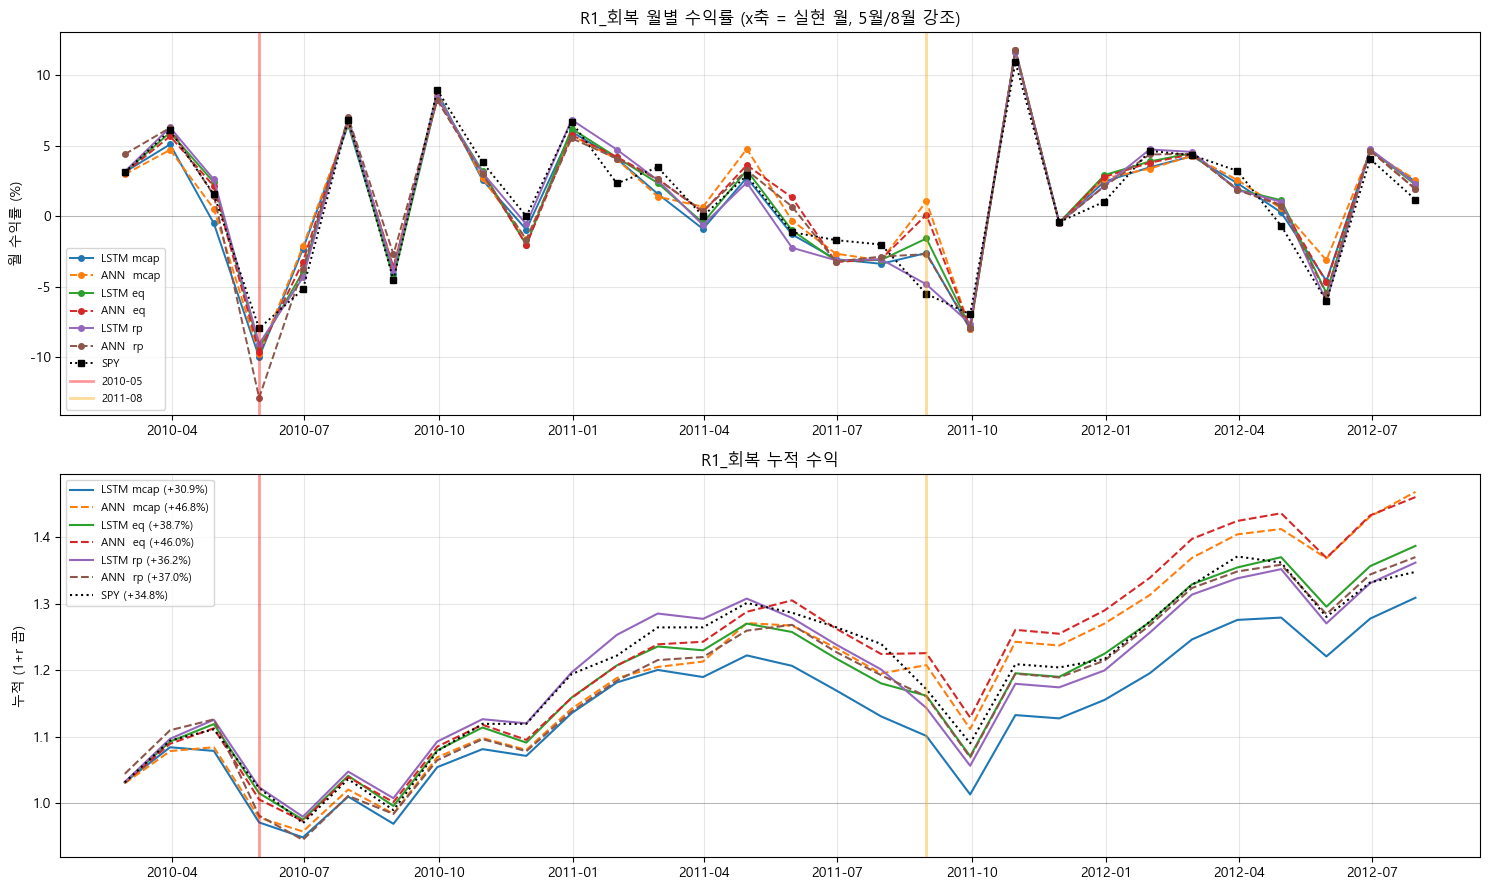

저장: c:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\99_analyze_ann_full\R1_decompose.png


In [8]:
# ── L20b. R1 catastrophic 월 분해 (정확한 indexing) ──
# 핵심 사실:
#   pkl ret[t] 는 'rebal date t' 에 indexed 되지만 VALUE 는 t 다음 월 realized return
#   따라서 2010-05 의 진짜 portfolio return = ret[2010-04-30] (4/30 리밸런싱 → 5월 보유)
#                2011-08 의 진짜 portfolio return = ret[2011-07-31]
#
# 종목 분해도 같은 alignment:
#   weights[rebal_date t] × ret_1m[t+1] = 그 portfolio 의 다음 월 realized contribution

# 패널: 종목별 월 수익 + 섹터
_panel_ret = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                         usecols=['date','ticker','ret_1m','gics_sector'],
                         parse_dates=['date'])
_ret_pivot = _panel_ret.set_index(['date','ticker'])['ret_1m'].unstack('ticker')
_sector    = (_panel_ret.dropna(subset=['gics_sector'])
              .drop_duplicates('ticker').set_index('ticker')['gics_sector'])


# 예측 데이터 로드 (hit rate / RMSE / Spearman 용)
from scipy.stats import spearmanr as _spearmanr
_lstm_csv = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                        parse_dates=['date'])
_ann_csv  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv', parse_dates=['date'])
_lstm_csv = _lstm_csv.replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])
_ann_csv  = _ann_csv.replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])


def _pred_quality_month(rebal_dt):
    """특정 rebal date 의 예측 quality (LSTM vs ANN): RMSE / Spearman / Hit rate (top·bottom 30%).
    LSTM 은 daily 라 month-end 가 거래일 아니면 그 달의 last trading day 사용."""
    L_month = _lstm_csv[(_lstm_csv['date'].dt.year == rebal_dt.year) &
                        (_lstm_csv['date'].dt.month == rebal_dt.month)]
    if len(L_month) > 0:
        last_lstm = L_month['date'].max()
        L = L_month[L_month['date']==last_lstm][['ticker','y_pred_ensemble','y_true']].dropna()
    else:
        L = pd.DataFrame(columns=['ticker','y_pred_ensemble','y_true'])
    A = _ann_csv [_ann_csv ['date']==rebal_dt][['ticker','y_pred_ensemble','y_true']].dropna()
    L = L.drop_duplicates('ticker').set_index('ticker')
    A = A.drop_duplicates('ticker').set_index('ticker')
    out = {}
    for lbl, df in [('LSTM', L), ('ANN', A)]:
        if len(df) < 20: out[lbl] = None; continue
        rmse = float(np.sqrt(((df['y_pred_ensemble']-df['y_true'])**2).mean()))
        sp   = float(_spearmanr(df['y_pred_ensemble'], df['y_true']).statistic)
        n = max(1, int(len(df)*0.30))
        actual_low  = set(df.nsmallest(n,'y_true').index)
        actual_high = set(df.nlargest (n,'y_true').index)
        pred_low    = set(df.nsmallest(n,'y_pred_ensemble').index)
        pred_high   = set(df.nlargest (n,'y_pred_ensemble').index)
        hit = (len(actual_low & pred_low) + len(actual_high & pred_high)) / (2*n)
        out[lbl] = dict(rmse=rmse, sp=sp, hit=hit, n=len(df))
    return out


def _decompose(rebal_dt, realiz_dt, slot_L, slot_A, title, top=10):
    """한 catastrophic 월 portfolio 분해: weight diff × realized ret + 예측 quality."""
    if slot_L not in loaded or slot_A not in loaded:
        print(f'  pkl 없음'); return
    wL = loaded[slot_L]['weights'].loc[rebal_dt].dropna()
    wA = loaded[slot_A]['weights'].loc[rebal_dt].dropna()
    common = wL.index.intersection(wA.index)
    rL_total = loaded[slot_L]['ret'].get(rebal_dt, np.nan)
    rA_total = loaded[slot_A]['ret'].get(rebal_dt, np.nan)

    print(f'\n{"="*100}')
    print(f'{title}  (rebal {rebal_dt.date()} → {realiz_dt.date()} 실현)')
    print(f'{"="*100}')
    print(f'  실현 portfolio ret: LSTM {rL_total*100:+.2f}%  |  ANN {rA_total*100:+.2f}%  (Δ {(rL_total-rA_total)*100:+.2f}%p)')

    # 예측 quality (model 별, 한 번만 — pw 무관)
    pq = _pred_quality_month(rebal_dt)
    if pq.get('LSTM') and pq.get('ANN'):
        pL, pA = pq['LSTM'], pq['ANN']
        print(f'  예측 quality (예측 정확도 — 그 시점):')
        print(f'    LSTM  RMSE={pL["rmse"]:.3f}  Spearman={pL["sp"]:+.3f}  HitRate={pL["hit"]:.1%}  (n={pL["n"]})')
        print(f'    ANN   RMSE={pA["rmse"]:.3f}  Spearman={pA["sp"]:+.3f}  HitRate={pA["hit"]:.1%}  (n={pA["n"]})')
        # 비교 한 줄
        better_pred = 'LSTM' if pL['hit'] > pA['hit'] else 'ANN'
        better_port = 'LSTM' if rL_total > rA_total else 'ANN'
        if better_pred != better_port:
            print(f'    ※ 예측은 {better_pred} 우위, portfolio 는 {better_port} 우위 — 역전 (정확한 예측 ≠ 좋은 portfolio)')
        else:
            print(f'    → 예측 우위 ({better_pred}) = portfolio 우위 ({better_port}) 일치')

    if realiz_dt not in _ret_pivot.index:
        print(f'  ret_pivot 에 {realiz_dt} 없음'); return
    r_all = _ret_pivot.loc[realiz_dt]

    df = pd.DataFrame({
        'L_w':        wL.reindex(common).fillna(0),
        'A_w':        wA.reindex(common).fillna(0),
        'ret_realiz': r_all.reindex(common),
    })
    df['Δw']        = df['L_w'] - df['A_w']
    df['L_contrib'] = df['L_w'] * df['ret_realiz']
    df['A_contrib'] = df['A_w'] * df['ret_realiz']
    df['Δcontrib']  = df['L_contrib'] - df['A_contrib']   # 음수 = LSTM 손해
    df['sector']    = [_sector.get(t,'?') for t in df.index]

    df_top = df.reindex(df['Δcontrib'].abs().sort_values(ascending=False).index).head(top)
    print(f'\n  Δ기여도 (LSTM - ANN) 절댓값 큰 종목 top {top}:')
    print(f'  {"ticker":<8s}{"L_w%":>8s}{"A_w%":>8s}{"Δw%":>10s}{"종목 ret%":>12s}{"Δ기여%":>10s}  섹터')
    print(f'  {"-"*92}')
    for tk, r in df_top.iterrows():
        print(f'  {tk:<8s}{r["L_w"]*100:>7.2f}%{r["A_w"]*100:>7.2f}%{r["Δw"]*100:>+9.2f}%{r["ret_realiz"]*100:>+11.2f}%{r["Δcontrib"]*100:>+9.3f}%  {r["sector"]}')

    sec = df.groupby('sector')['Δcontrib'].sum().sort_values()
    print(f'\n  섹터별 Δ기여 합 (음수=LSTM 손해):')
    for s, v in sec.head(3).items():  print(f'    {s:<28s}  {v*100:>+7.3f}%')
    for s, v in sec.tail(3).items():  print(f'    {s:<28s}  {v*100:>+7.3f}%')


# ─── 2010-05 (Greece + Flash Crash) 3 weighting 분해 ───
print('═'*100)
print('★ 2010-05 (Greece + Flash Crash) — 모든 weighting 분해')
print('═'*100)
for pw in ['mcap','eq','rp']:
    _decompose(pd.Timestamp('2010-04-30'), pd.Timestamp('2010-05-31'),
               f'mat_mcap_{pw}_fpm_pap', f'mat_mcap_{pw}_fpm_pap_ann',
               f'2010-05  p_w={pw}')

# ─── 2011-08 (S&P 강등 + Euro 본격화) 3 weighting 분해 ───
print()
print('═'*100)
print('★ 2011-08 (S&P 강등 + Euro 본격화) — 모든 weighting 분해')
print('═'*100)
for pw in ['mcap','eq','rp']:
    _decompose(pd.Timestamp('2011-07-31'), pd.Timestamp('2011-08-31'),
               f'mat_mcap_{pw}_fpm_pap', f'mat_mcap_{pw}_fpm_pap_ann',
               f'2011-08  p_w={pw}')


# ─── R1 zoom plot (correct indexing) ───
print()
print('═'*100)
print('R1 zoom chart — 정확한 indexing (x축 = realization month)')
print('═'*100)

_SLOTS_PLOT = {
    'LSTM mcap': 'mat_mcap_mcap_fpm_pap', 'ANN  mcap': 'mat_mcap_mcap_fpm_pap_ann',
    'LSTM eq':   'mat_mcap_eq_fpm_pap',   'ANN  eq':   'mat_mcap_eq_fpm_pap_ann',
    'LSTM rp':   'mat_mcap_rp_fpm_pap',   'ANN  rp':   'mat_mcap_rp_fpm_pap_ann',
}
_colors = {'LSTM mcap':'C0','ANN  mcap':'C1','LSTM eq':'C2','ANN  eq':'C3','LSTM rp':'C4','ANN  rp':'C5'}

# rebal date → realization month-end 으로 shift
_plot_rets = {}
for lbl, name in _SLOTS_PLOT.items():
    if name in loaded:
        s = loaded[name]['ret'].dropna().copy()
        s.index = s.index + pd.offsets.MonthEnd(1)
        _plot_rets[lbl] = s
_spy = loaded['mat_mcap_mcap_fpm_pap']['spy_ret'].copy()
_spy.index = _spy.index + pd.offsets.MonthEnd(1)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
ax = axes[0]
for n, r in _plot_rets.items():
    sub = r.loc['2010-02-28':'2012-07-31']
    ls = '-' if 'LSTM' in n else '--'
    ax.plot(sub.index, sub.values*100, label=n, lw=1.4, color=_colors[n],
            linestyle=ls, marker='o', markersize=4)
spy_r = _spy.loc['2010-02-28':'2012-07-31']
ax.plot(spy_r.index, spy_r.values*100, label='SPY', lw=1.4, color='black',
        linestyle=':', marker='s', markersize=4)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(pd.Timestamp('2010-05-31'), color='red', alpha=0.4, lw=2, label='2010-05')
ax.axvline(pd.Timestamp('2011-08-31'), color='orange', alpha=0.4, lw=2, label='2011-08')
ax.set_title('R1_회복 월별 수익률 (x축 = 실현 월, 5월/8월 강조)')
ax.set_ylabel('월 수익률 (%)'); ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
for n, r in _plot_rets.items():
    sub = r.loc['2010-02-28':'2012-07-31']
    cum = (1+sub).cumprod()
    ls = '-' if 'LSTM' in n else '--'
    ax.plot(cum.index, cum.values, label=f'{n} ({(cum.iloc[-1]-1)*100:+.1f}%)',
            lw=1.5, color=_colors[n], linestyle=ls)
cum_spy = (1+_spy.loc['2010-02-28':'2012-07-31']).cumprod()
ax.plot(cum_spy.index, cum_spy.values, label=f'SPY ({(cum_spy.iloc[-1]-1)*100:+.1f}%)',
        lw=1.5, color='black', linestyle=':')
ax.axhline(1.0, color='k', lw=0.5, alpha=0.3)
ax.axvline(pd.Timestamp('2010-05-31'), color='red', alpha=0.4, lw=2)
ax.axvline(pd.Timestamp('2011-08-31'), color='orange', alpha=0.4, lw=2)
ax.set_title('R1_회복 누적 수익')
ax.set_ylabel('누적 (1+r 곱)'); ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'R1_decompose.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'저장: {OUT_DIR / "R1_decompose.png"}')


## L20c. Anchor SET 2 — regime 별 절대 Sharpe / Sortino

**Δ 만 보면 해석 왜곡 가능** — anchor (prior=mcap, q=fpm, omega=pap) 에서 p_w 만 바꿨을 때
LSTM 과 ANN 각각의 절대 Sharpe / Sortino 를 regime 별로 표시.

예: Δ Sh (R2) = +0.013 (eq) 만 보면 "거의 동률" 같지만, 실제 둘 다 1.4+ 라서 high level performance 임.
반대로 Δ Sh (R2) = +0.212 (mcap) 인데 둘 다 1.0 대 → "큰 우위지만 high level 아님" 으로 다르게 해석.


In [9]:
# ── L20c. Anchor SET 2 절대 Sharpe / Sortino (p_w 변경) ──
ANCHOR_BASE = 'mat_mcap_{pw}_fpm_pap'

PERIODS_L20c = [('R1_회복',   '2010-01-01', '2012-06-30'),
                ('R2_확장',   '2012-07-01', '2019-12-31'),
                ('R3_위기',   '2020-01-01', '2023-06-30'),
                ('R4_정상화', '2023-07-01', '2025-12-31'),
                ('전체',     '2010-01-01', '2025-12-31')]


def _abs_sh_so(name, s, e):
    if name not in loaded: return np.nan, np.nan, 0
    r = loaded[name]['ret'].dropna()
    r = r[(r.index >= pd.Timestamp(s)) & (r.index <= pd.Timestamp(e)) & (r.index <= pd.Timestamp(CUTOFF))]
    if len(r) < 6: return np.nan, np.nan, 0
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    sh = float(exc.mean()*12/vol) if vol>0 else np.nan
    dn = r[r<0].std() * np.sqrt(12)
    so = float(exc.mean()*12/dn) if dn and dn>0 else np.nan
    return sh, so, len(r)


# 표 출력: Sharpe
print('='*100)
print('Anchor (prior=mcap, q=fpm, omega=pap) regime 별 절대 Sharpe — p_w 변경')
print('='*100)
print(f'{"period":<12}{"n":>4}', end='')
for pw in ['mcap','eq','rp']:
    print(f'  | {pw+" LSTM":>9}{pw+" ANN":>9}{"Δ":>7}', end='')
print()
print('-'*100)
for plbl, s, e in PERIODS_L20c:
    print(f'{plbl:<12}', end='')
    n_print = None
    for i, pw in enumerate(['mcap','eq','rp']):
        L = ANCHOR_BASE.format(pw=pw)
        A = L + '_ann'
        shL, _, n = _abs_sh_so(L, s, e)
        shA, _, _ = _abs_sh_so(A, s, e)
        if n_print is None: n_print = n
        if i == 0: print(f'{n_print:>4}', end='')
        d = shL - shA if not (np.isnan(shL) or np.isnan(shA)) else np.nan
        print(f'  | {shL:>+9.3f}{shA:>+9.3f}{d:>+7.3f}', end='')
    print()

# 표 출력: Sortino
print()
print('='*100)
print('동일 anchor — regime 별 절대 Sortino')
print('='*100)
print(f'{"period":<12}{"n":>4}', end='')
for pw in ['mcap','eq','rp']:
    print(f'  | {pw+" LSTM":>9}{pw+" ANN":>9}{"Δ":>7}', end='')
print()
print('-'*100)
for plbl, s, e in PERIODS_L20c:
    print(f'{plbl:<12}', end='')
    n_print = None
    for i, pw in enumerate(['mcap','eq','rp']):
        L = ANCHOR_BASE.format(pw=pw)
        A = L + '_ann'
        _, soL, n = _abs_sh_so(L, s, e)
        _, soA, _ = _abs_sh_so(A, s, e)
        if n_print is None: n_print = n
        if i == 0: print(f'{n_print:>4}', end='')
        d = soL - soA if not (np.isnan(soL) or np.isnan(soA)) else np.nan
        print(f'  | {soL:>+9.3f}{soA:>+9.3f}{d:>+7.3f}', end='')
    print()

# 해석
print()
print('='*100)
print('해석 도움말 (Δ 의 context 가 절대값에 의존)')
print('='*100)
print('  - 둘 다 절대 Sharpe 1.0+ 면 high-level performance → Δ 작아도 둘 다 성공')
print('  - 둘 다 절대 Sharpe < 1.0 면 mediocre → Δ 가 크다고 의미 있는 건 아님')
print('  - 핵심: p_w 변경이 LSTM 우위 자체보다 ANN 의 catch-up 폭에 더 큰 영향 줄 수 있음')
print('  - mcap → eq 변경시 ANN Sh 가 LSTM 보다 더 크게 향상 → Δ 좁아짐')


Anchor (prior=mcap, q=fpm, omega=pap) regime 별 절대 Sharpe — p_w 변경
period         n  | mcap LSTM mcap ANN      Δ  |   eq LSTM   eq ANN      Δ  |   rp LSTM   rp ANN      Δ
----------------------------------------------------------------------------------------------------
R1_회복         30  |    +0.738   +1.059 -0.321  |    +0.872   +1.024 -0.152  |    +0.806   +0.809 -0.003
R2_확장         90  |    +1.287   +1.076 +0.212  |    +1.421   +1.408 +0.013  |    +1.344   +1.311 +0.033
R3_위기         42  |    +0.702   +0.850 -0.148  |    +0.888   +0.705 +0.183  |    +0.870   +0.714 +0.155
R4_정상화        30  |    +0.940   +0.712 +0.228  |    +1.066   +0.868 +0.198  |    +1.102   +0.900 +0.202
전체           192  |    +0.946   +0.945 +0.000  |    +1.099   +1.049 +0.050  |    +1.054   +0.970 +0.084

동일 anchor — regime 별 절대 Sortino
period         n  | mcap LSTM mcap ANN      Δ  |   eq LSTM   eq ANN      Δ  |   rp LSTM   rp ANN      Δ
------------------------------------------------------------------------

## L_crisis. 위기 구간 LSTM vs ANN 예측 quality

**목적**: BL 결과 차이를 만든 catastrophic 월의 예측 quality 검증.

**측정**:
- RMSE (log daily_std 공간)
- Spearman rank correlation (vol ranking 정확도)
- Hit rate (실제 top/bottom 30% 와 예측 일치율)

**기간**: 레짐별 + 특정 위기 월 (2011-08 Euro, 2020-03 COVID 등)


In [10]:
# ── L_crisis. 위기 구간 LSTM vs ANN 예측 quality ──
from scipy.stats import spearmanr

lstm_pred = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                        parse_dates=['date'])
ann_pred  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv', parse_dates=['date'])

# 정리: inf/NaN 제거, monthly frequency 통일 (LSTM 은 daily 라 ANN 의 month-end 만 필터)
lstm_pred = (lstm_pred[['date','ticker','y_pred_ensemble','y_true']]
             .replace([np.inf, -np.inf], np.nan).dropna())
ann_pred  = (ann_pred[['date','ticker','y_pred_ensemble','y_true']]
             .replace([np.inf, -np.inf], np.nan).dropna())

ann_dates = set(ann_pred['date'].unique())
lstm_pred = lstm_pred[lstm_pred['date'].isin(ann_dates)].copy()
# duplicate 제거 (LSTM CSV 에 같은 (date,ticker) 중복 있을 경우)
lstm_pred = lstm_pred.drop_duplicates(subset=['date','ticker'], keep='last')
ann_pred  = ann_pred.drop_duplicates(subset=['date','ticker'], keep='last')

# (A) own-sample 분석용 (각 모델의 full 예측)
lstm_own = lstm_pred[lstm_pred['date'] <= CUTOFF].copy()
ann_own  = ann_pred[ann_pred['date'] <= CUTOFF].copy()
print(f'LSTM own (month-end, inf 제거): {len(lstm_own):,}개')
print(f'ANN  own:                     {len(ann_own):,}개')

# (B) intersection — 공통 (date,ticker) (단, BL 이 실제 쓰는 건 아님)
merged = lstm_pred.merge(
    ann_pred[['date','ticker','y_pred_ensemble']].rename(columns={'y_pred_ensemble':'y_pred_ann'}),
    on=['date','ticker'], how='inner'
).rename(columns={'y_pred_ensemble':'y_pred_lstm'})
merged = merged[merged['date'] <= CUTOFF].copy()
print(f'intersection (참고용):         {len(merged):,}개')

def _metrics_period(df_sub):
    if len(df_sub) < 5:
        return None
    rmse_l = float(np.sqrt(((df_sub['y_pred_lstm'] - df_sub['y_true'])**2).mean()))
    rmse_a = float(np.sqrt(((df_sub['y_pred_ann']  - df_sub['y_true'])**2).mean()))
    sp_l = float(spearmanr(df_sub['y_pred_lstm'], df_sub['y_true']).statistic)
    sp_a = float(spearmanr(df_sub['y_pred_ann'],  df_sub['y_true']).statistic)

    def _hit_rate(df, pred_col):
        rates = []
        for dt, g in df.groupby('date'):
            if len(g) < 20: continue
            n = max(1, int(len(g) * 0.30))
            actual_low  = set(g.nsmallest(n, 'y_true')['ticker'])
            actual_high = set(g.nlargest(n,  'y_true')['ticker'])
            pred_low    = set(g.nsmallest(n, pred_col)['ticker'])
            pred_high   = set(g.nlargest(n,  pred_col)['ticker'])
            rates.append((len(actual_low & pred_low) + len(actual_high & pred_high)) / (2*n))
        return float(np.mean(rates)) if rates else np.nan

    hit_l = _hit_rate(df_sub, 'y_pred_lstm')
    hit_a = _hit_rate(df_sub, 'y_pred_ann')

    return dict(rmse_lstm=rmse_l, rmse_ann=rmse_a, sp_lstm=sp_l, sp_ann=sp_a,
                hit_lstm=hit_l, hit_ann=hit_a, n_obs=len(df_sub))


# (1) 레짐별 — own sample (각 모델의 full 예측, BL 이 실제 사용하는 분포)
print('\n' + '='*84)
print('(1A) 레짐별 LSTM vs ANN 예측 quality — OWN SAMPLE (BL 이 실제 사용)')
print('='*84)
def _own_metrics(df, pred_col, s, e):
    sub = df[(df['date'] >= s) & (df['date'] <= e)]
    if len(sub) < 5: return None
    rmse = float(np.sqrt(((sub[pred_col] - sub['y_true'])**2).mean()))
    sp = float(spearmanr(sub[pred_col], sub['y_true']).statistic)
    # hit rate
    rates = []
    for dt, g in sub.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g) * 0.30))
        actual_low  = set(g.nsmallest(n, 'y_true')['ticker'])
        actual_high = set(g.nlargest(n,  'y_true')['ticker'])
        pred_low    = set(g.nsmallest(n, pred_col)['ticker'])
        pred_high   = set(g.nlargest(n,  pred_col)['ticker'])
        rates.append((len(actual_low & pred_low) + len(actual_high & pred_high)) / (2*n))
    hit = float(np.mean(rates)) if rates else np.nan
    return dict(rmse=rmse, sp=sp, hit=hit, n=len(sub))

for lbl, s, e in REGIMES:
    mL = _own_metrics(lstm_own, 'y_pred_ensemble', s, e)
    mA = _own_metrics(ann_own,  'y_pred_ensemble', s, e)
    if mL is None or mA is None:
        print(f'  {lbl}: 데이터 부족'); continue
    print(f'\n[{lbl}] (LSTM n={mL["n"]:,} / ANN n={mA["n"]:,})')
    print(f'  RMSE      LSTM={mL["rmse"]:.4f}  ANN={mA["rmse"]:.4f}  (L-A={mL["rmse"]-mA["rmse"]:+.4f})')
    print(f'  Spearman  LSTM={mL["sp"]:.3f}   ANN={mA["sp"]:.3f}   (diff={mL["sp"]-mA["sp"]:+.3f})')
    print(f'  Hit rate  LSTM={mL["hit"]:.3f}   ANN={mA["hit"]:.3f}   (diff={mL["hit"]-mA["hit"]:+.3f})')

# (1B) intersection — 참고
print('\n' + '='*84)
print('(1B) 레짐별 LSTM vs ANN — INTERSECTION (공통 date+ticker, 참고)')
print('='*84)
for lbl, s, e in REGIMES:
    sub = merged[(merged['date'] >= s) & (merged['date'] <= e)]
    m = _metrics_period(sub)
    if m is None: continue
    print(f'  [{lbl}] (n={m["n_obs"]:,})  LSTM RMSE={m["rmse_lstm"]:.4f} Sp={m["sp_lstm"]:.3f}'
          f'  |  ANN RMSE={m["rmse_ann"]:.4f} Sp={m["sp_ann"]:.3f}')


# (2) 위기 월 직접 분석
print('\n\n' + '='*84)
print('(2) 특정 위기 월 LSTM vs ANN 예측 quality')
print('='*84)

rL = loaded.get(ANCHOR_L, {}).get('ret')
rA = loaded.get(ANCHOR_A, {}).get('ret')
if rL is None or rA is None:
    print('anchor pkl 없음 — skip')
else:
    ret_diff = (rL - rA).dropna()
    ret_diff = ret_diff[ret_diff.index <= CUTOFF]

    crisis_months = []
    for lbl, s, e in [('R1_회복', '2010-01-01', '2012-06-30'),
                      ('R3_위기', '2020-01-01', '2023-06-30'),
                      ('R4_정상화', '2023-07-01', '2025-12-31')]:
        sub = ret_diff[(ret_diff.index >= s) & (ret_diff.index <= e)]
        for dt in sub.nsmallest(3).index:
            crisis_months.append((str(dt.date()), lbl, float(sub[dt])))

    explicit = [
        ('2011-08-31', 'Euro+S&P강등'),
        ('2011-09-30', 'Greek위기'),
        ('2020-03-31', 'COVID'),
        ('2022-09-30', '연준 hike'),
    ]
    for dt_str, lbl in explicit:
        if dt_str not in [c[0] for c in crisis_months]:
            crisis_months.append((dt_str, lbl, None))

    print(f'\n{"월":<14}{"이벤트":<14}{"BL ret diff":>12}{"":>4}'
          f'{"LSTM RMSE":>10}{"ANN RMSE":>10}{"diff":>8}'
          f'{"LSTM hit":>10}{"ANN hit":>10}{"diff":>8}')
    print('-'*100)

    for dt_str, ev, _ in sorted(crisis_months):
        sub = merged[merged['date'] == pd.Timestamp(dt_str)]
        if len(sub) == 0:
            continue
        rmse_l = float(np.sqrt(((sub['y_pred_lstm'] - sub['y_true'])**2).mean()))
        rmse_a = float(np.sqrt(((sub['y_pred_ann']  - sub['y_true'])**2).mean()))
        n = max(1, int(len(sub) * 0.30))
        actual_low  = set(sub.nsmallest(n, 'y_true')['ticker'])
        actual_high = set(sub.nlargest(n,  'y_true')['ticker'])
        pred_l_low  = set(sub.nsmallest(n, 'y_pred_lstm')['ticker'])
        pred_l_high = set(sub.nlargest(n,  'y_pred_lstm')['ticker'])
        pred_a_low  = set(sub.nsmallest(n, 'y_pred_ann')['ticker'])
        pred_a_high = set(sub.nlargest(n,  'y_pred_ann')['ticker'])
        hit_l = (len(actual_low & pred_l_low) + len(actual_high & pred_l_high)) / (2*n)
        hit_a = (len(actual_low & pred_a_low) + len(actual_high & pred_a_high)) / (2*n)
        bl = ret_diff.get(pd.Timestamp(dt_str), np.nan)
        bl_str = f'{bl:+.4f}' if pd.notna(bl) else '   --   '
        print(f'{dt_str:<14}{ev:<14}{bl_str:>12}    '
              f'{rmse_l:>10.4f}{rmse_a:>10.4f}{rmse_l-rmse_a:>+8.4f}'
              f'{hit_l:>10.3f}{hit_a:>10.3f}{hit_l-hit_a:>+8.3f}')

# (3) 결론 요약
print('\n\n' + '='*84)
print('(3) 결론 (예시 가설)')
print('='*84)
print('  - 평시 (R2_확장): LSTM RMSE 우위, Spearman 우위 (예상)')
print('  - 위기 시 (R1, R3): 둘 다 RMSE 폭증, LSTM 우위 폭 좁아짐')
print('  - 특정 catastrophic 월: LSTM 의 잘못된 음수 Q 가 잘못된 view 강하게 베팅 → 손실')
print('  - ANN 의 거친 양수 Q 가 우연히 안전한 conservative 베팅 → outperform')
print('  실제 결과로 검증 필요.')


LSTM own (month-end, inf 제거): 72,453개
ANN  own:                     102,781개
intersection (참고용):         71,709개

(1A) 레짐별 LSTM vs ANN 예측 quality — OWN SAMPLE (BL 이 실제 사용)

[R1_회복] (LSTM n=9,728 / ANN n=14,613)
  RMSE      LSTM=0.3168  ANN=0.5885  (L-A=-0.2717)
  Spearman  LSTM=0.764   ANN=0.548   (diff=+0.216)
  Hit rate  LSTM=0.710   ANN=0.681   (diff=+0.030)

[R2_확장] (LSTM n=33,748 / ANN n=47,529)
  RMSE      LSTM=0.3633  ANN=0.4784  (L-A=-0.1150)
  Spearman  LSTM=0.597   ANN=0.507   (diff=+0.090)
  Hit rate  LSTM=0.628   ANN=0.604   (diff=+0.024)

[R3_위기] (LSTM n=17,159 / ANN n=23,811)
  RMSE      LSTM=0.3390  ANN=0.5303  (L-A=-0.1913)
  Spearman  LSTM=0.696   ANN=0.377   (diff=+0.318)
  Hit rate  LSTM=0.660   ANN=0.620   (diff=+0.040)

[R4_정상화] (LSTM n=11,818 / ANN n=16,828)
  RMSE      LSTM=0.3729  ANN=0.4041  (L-A=-0.0312)
  Spearman  LSTM=0.649   ANN=0.540   (diff=+0.109)
  Hit rate  LSTM=0.635   ANN=0.616   (diff=+0.019)

(1B) 레짐별 LSTM vs ANN — INTERSECTION (공통 date+ticker, 참고

## L_synthesis. 4단 사슬 narrative — Anchor pair 레짐별 분해

**Anchor**: `mat_mcap_mcap_fpm_pap` (LSTM ensemble) vs `_ann` (ANN)

각 레짐별로 BL 우위가 어디서 기인하는지 추적:
- **① 예측 quality** (RMSE, Spearman) — own sample 기준
- **② Q view** (mean, 음수 비율) — BL 의 view 강도/방향
- **③ Portfolio composition** (저변동 비중, 활성 종목) — Q 가 weight 에 어떻게 반영됐는지
- **④ Return** (Sharpe, Sortino, MDD, CAGR) — 최종 결과

L_crisis (예측), L18 (Q + 가중치) 셀이 먼저 실행되어 있어야 함.


In [11]:
# ── L_synthesis. 4단 사슬 자동 분해 — anchor pair × 3 레짐 ──
from IPython.display import display, Markdown

def _anchor_ret_metrics(name, s, e):
    if name not in loaded: return None
    r = loaded[name]['ret'].dropna()
    r = r[(r.index >= s) & (r.index <= e) & (r.index <= pd.Timestamp(CUTOFF))]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0); mka = spy_ret.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = r[r < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    cagr = (1 + r).prod() ** (12 / len(r)) - 1
    return dict(Sh=sh, So=so, MDD=mdd, CAGR=cagr, n=len(r))


def _anchor_q_stats(name, s, e):
    if name not in loaded: return None
    meta = loaded[name].get('meta', {})
    Q = meta.get('Q')
    if Q is None: return None
    q = Q[(Q.index >= pd.Timestamp(s)) & (Q.index <= pd.Timestamp(e))]
    if len(q) == 0: return None
    return dict(mean=q.mean(), neg=(q<0).mean(), abs_mean=q.abs().mean())


# L_crisis 의 lstm_own / ann_own, L18 의 _composition_stats 재사용
cL_full = _composition_stats(ANCHOR_L)
cA_full = _composition_stats(ANCHOR_A)

for lbl, s, e in REGIMES:
    pL = _own_metrics(lstm_own, 'y_pred_ensemble', s, e)
    pA = _own_metrics(ann_own,  'y_pred_ensemble', s, e)
    qL = _anchor_q_stats(ANCHOR_L, s, e)
    qA = _anchor_q_stats(ANCHOR_A, s, e)
    cL_r = cL_full.loc[s:e] if cL_full is not None else None
    cA_r = cA_full.loc[s:e] if cA_full is not None else None
    rL = _anchor_ret_metrics(ANCHOR_L, s, e)
    rA = _anchor_ret_metrics(ANCHOR_A, s, e)

    if None in (pL, pA, qL, qA, rL, rA) or cL_r is None or cA_r is None:
        print(f'[{lbl}] 데이터 부족 — skip'); continue

    display(Markdown(f'### {lbl}  ({rL["n"]}mo)'))

    def _sgn(v, fmt='{:+.3f}', pct=False):
        if pct: return f'{v*100:+.2f}%p'
        return fmt.format(v)

    lvL_m = cL_r['lv_weight'].mean(); lvA_m = cA_r['lv_weight'].mean()
    hvL_m = cL_r['hv_weight'].mean(); hvA_m = cA_r['hv_weight'].mean()

    tbl = pd.DataFrame([
        {'단계': '① 예측 RMSE',    'LSTM': f'{pL["rmse"]:.3f}',  'ANN': f'{pA["rmse"]:.3f}',  'Δ (L-A)': _sgn(pL['rmse']-pA['rmse'])},
        {'단계': '① 예측 Spearman','LSTM': f'{pL["sp"]:.3f}',    'ANN': f'{pA["sp"]:.3f}',    'Δ (L-A)': _sgn(pL['sp']-pA['sp'])},
        {'단계': '② Q 평균',        'LSTM': f'{qL["mean"]:+.5f}', 'ANN': f'{qA["mean"]:+.5f}', 'Δ (L-A)': _sgn(qL['mean']-qA['mean'], fmt='{:+.5f}')},
        {'단계': '② Q 음수 비율',   'LSTM': f'{qL["neg"]:.1%}',   'ANN': f'{qA["neg"]:.1%}',   'Δ (L-A)': _sgn(qL['neg']-qA['neg'], pct=True)},
        {'단계': '② |Q| 평균',      'LSTM': f'{qL["abs_mean"]:.5f}', 'ANN': f'{qA["abs_mean"]:.5f}', 'Δ (L-A)': _sgn(qL['abs_mean']-qA['abs_mean'], fmt='{:+.5f}')},
        {'단계': '③ 저변동 비중',   'LSTM': f'{lvL_m:.2%}',  'ANN': f'{lvA_m:.2%}',  'Δ (L-A)': _sgn(lvL_m-lvA_m, pct=True)},
        {'단계': '③ 고변동 비중',   'LSTM': f'{hvL_m:.2%}',  'ANN': f'{hvA_m:.2%}',  'Δ (L-A)': _sgn(hvL_m-hvA_m, pct=True)},
        {'단계': '③ L-H spread',    'LSTM': f'{(lvL_m-hvL_m):+.2%}', 'ANN': f'{(lvA_m-hvA_m):+.2%}', 'Δ (L-A)': _sgn((lvL_m-hvL_m)-(lvA_m-hvA_m), pct=True)},
        {'단계': '③ 활성 종목 수',  'LSTM': f'{cL_r["active_n"].mean():.0f}',   'ANN': f'{cA_r["active_n"].mean():.0f}',   'Δ (L-A)': f'{cL_r["active_n"].mean()-cA_r["active_n"].mean():+.0f}'},
        {'단계': '④ Sharpe',        'LSTM': f'{rL["Sh"]:+.3f}',  'ANN': f'{rA["Sh"]:+.3f}',  'Δ (L-A)': _sgn(rL['Sh']-rA['Sh'])},
        {'단계': '④ Sortino',       'LSTM': f'{rL["So"]:+.3f}',  'ANN': f'{rA["So"]:+.3f}',  'Δ (L-A)': _sgn(rL['So']-rA['So'])},
        {'단계': '④ MDD',           'LSTM': f'{rL["MDD"]:.2%}',  'ANN': f'{rA["MDD"]:.2%}',  'Δ (L-A)': _sgn(rL['MDD']-rA['MDD'], pct=True)},
        {'단계': '④ CAGR',          'LSTM': f'{rL["CAGR"]:.2%}', 'ANN': f'{rA["CAGR"]:.2%}', 'Δ (L-A)': _sgn(rL['CAGR']-rA['CAGR'], pct=True)},
    ])

    sty = (tbl.style
        .set_properties(**{'text-align': 'right', 'font-size': '12.5px', 'padding': '4px 10px'})
        .set_table_styles([
            {'selector': 'th', 'props': 'background-color: #eef2f6; font-weight: bold; '
                                         'text-align: center; padding: 6px; border-bottom: 2px solid #888;'},
            {'selector': 'td:first-child', 'props': 'text-align: left; font-weight: 600; background-color: #fafbfc;'},
        ])
        .hide(axis='index'))
    display(sty)

    # BL 메커니즘 기반 자동 해석
    # P matrix = low-vol vs high-vol spread bet
    # Q > 0 → low-vol overweight, Q < 0 → high-vol overweight
    winner = 'LSTM' if rL['Sh'] > rA['Sh'] else 'ANN'
    d_sh = rL['Sh'] - rA['Sh']
    d_q   = qL['mean'] - qA['mean']           # 음수 → LSTM Q 가 더 negative (=고변동 더 베팅)
    d_negq = qL['neg'] - qA['neg']            # 양수 → LSTM 이 음수 Q 비율 더 높음
    d_hv  = hvL_m - hvA_m                     # 양수 → LSTM 이 고변동 더 담음
    d_lv  = lvL_m - lvA_m                     # 음수 → LSTM 이 저변동 덜 담음
    d_pred = pL['rmse'] - pA['rmse']

    print(f'  → BL Sharpe 우위: {winner} (Δ={d_sh:+.3f})')
    print(f'  → BL 메커니즘 (P = low-vol vs high-vol spread):')
    print(f'      Q 평균 차이 (L-A) = {d_q:+.5f}  → LSTM Q 가 {"더 negative (고변동 베팅 강함)" if d_q<0 else "덜 negative"}')
    print(f'      음수 Q 비율 차이  = {d_negq*100:+.1f}%p  → LSTM 이 {"더 자주" if d_negq>0 else "덜 자주"} 고변동 베팅')
    print(f'      가중치 결과: LSTM 고변동 {hvL_m:.1%} vs ANN {hvA_m:.1%}  (Δ={d_hv*100:+.1f}%p)')
    print(f'                   LSTM 저변동 {lvL_m:.1%} vs ANN {lvA_m:.1%}  (Δ={d_lv*100:+.1f}%p)')
    # 메커니즘 일관성 체크
    if d_q < 0 and d_hv > 0:
        print(f'      ✓ Q→weight 인과 일관: LSTM Q 더 negative → 고변동 비중 더 큼')
    elif d_q > 0 and d_hv < 0:
        print(f'      ✓ Q→weight 인과 일관: LSTM Q 더 positive → 저변동 비중 더 큼')
    else:
        print(f'      ⚠ Q→weight 인과 약함 (prior/omega 가 dominant 한 슬롯일 수 있음)')

    # 한 줄 결론
    if winner == 'ANN' and d_q < 0:
        print(f'  → 해석: LSTM 의 더 강한 negative Q (예측 정확도에 기반) 가 고변동에 over-bet → ')
        print(f'         {lbl} 환경에서 고변동이 underperform → ANN 의 더 약한 Q 가 더 안전')
    elif winner == 'LSTM' and d_q < 0:
        print(f'  → 해석: LSTM 의 negative Q + 정확한 고변동 종목 식별이 맞아떨어짐')
        print(f'         ({lbl} 에서 고변동 underperform 했고, LSTM 이 정확히 underweight)')
    elif winner == 'LSTM' and d_q > 0:
        print(f'  → 해석: LSTM 의 positive Q (저변동 우위 view) + 정확한 ranking')
    print()

# 전체 TEST (참고)
display(Markdown('### 전체 TEST (2010-01 ~ 2025-12, 192mo)'))
rL = _anchor_ret_metrics(ANCHOR_L, '2010-01-01', '2025-12-31')
rA = _anchor_ret_metrics(ANCHOR_A, '2010-01-01', '2025-12-31')
print(f'  LSTM: Sh={rL["Sh"]:+.3f}  So={rL["So"]:+.3f}  MDD={rL["MDD"]:.2%}  CAGR={rL["CAGR"]:.2%}')
print(f'  ANN : Sh={rA["Sh"]:+.3f}  So={rA["So"]:+.3f}  MDD={rA["MDD"]:.2%}  CAGR={rA["CAGR"]:.2%}')
print(f'  → 전체 평균은 거의 동률 — 레짐 분해 (위) 가 진짜 story')


### R1_회복  (30mo)

단계,LSTM,ANN,Δ (L-A)
① 예측 RMSE,0.317,0.588,-0.272
① 예측 Spearman,0.764,0.548,+0.216
② Q 평균,+0.00012,+0.00222,-0.00210
② Q 음수 비율,43.3%,3.3%,+40.00%p
② |Q| 평균,0.00159,0.00227,-0.00068
③ 저변동 비중,55.80%,59.95%,-4.15%p
③ 고변동 비중,8.76%,8.23%,+0.52%p
③ L-H spread,+47.05%,+51.72%,-4.67%p
③ 활성 종목 수,151,135,+16
④ Sharpe,+0.738,+1.059,-0.321


  → BL Sharpe 우위: ANN (Δ=-0.321)
  → BL 메커니즘 (P = low-vol vs high-vol spread):
      Q 평균 차이 (L-A) = -0.00210  → LSTM Q 가 더 negative (고변동 베팅 강함)
      음수 Q 비율 차이  = +40.0%p  → LSTM 이 더 자주 고변동 베팅
      가중치 결과: LSTM 고변동 8.8% vs ANN 8.2%  (Δ=+0.5%p)
                   LSTM 저변동 55.8% vs ANN 60.0%  (Δ=-4.1%p)
      ✓ Q→weight 인과 일관: LSTM Q 더 negative → 고변동 비중 더 큼
  → 해석: LSTM 의 더 강한 negative Q (예측 정확도에 기반) 가 고변동에 over-bet → 
         R1_회복 환경에서 고변동이 underperform → ANN 의 더 약한 Q 가 더 안전



### R2_확장  (90mo)

단계,LSTM,ANN,Δ (L-A)
① 예측 RMSE,0.363,0.478,-0.115
① 예측 Spearman,0.597,0.507,+0.090
② Q 평균,-0.00105,-0.00011,-0.00094
② Q 음수 비율,61.1%,44.4%,+16.67%p
② |Q| 평균,0.00290,0.00222,+0.00067
③ 저변동 비중,43.25%,45.48%,-2.23%p
③ 고변동 비중,20.63%,18.29%,+2.34%p
③ L-H spread,+22.62%,+27.19%,-4.57%p
③ 활성 종목 수,178,172,+6
④ Sharpe,+1.287,+1.076,+0.212


...

### R4_정상화  (30mo)

단계,LSTM,ANN,Δ (L-A)
① 예측 RMSE,0.373,0.404,-0.031
① 예측 Spearman,0.649,0.540,+0.109
② Q 평균,-0.01003,-0.00987,-0.00016
② Q 음수 비율,80.0%,90.0%,-10.00%p
② |Q| 평균,0.01111,0.01000,+0.00112
③ 저변동 비중,25.07%,26.36%,-1.29%p
③ 고변동 비중,39.66%,36.76%,+2.90%p
③ L-H spread,-14.59%,-10.40%,-4.19%p
③ 활성 종목 수,169,171,-2
④ Sharpe,+0.940,+0.712,+0.228


  → BL Sharpe 우위: LSTM (Δ=+0.228)
  → BL 메커니즘 (P = low-vol vs high-vol spread):
      Q 평균 차이 (L-A) = -0.00016  → LSTM Q 가 더 negative (고변동 베팅 강함)
      음수 Q 비율 차이  = -10.0%p  → LSTM 이 덜 자주 고변동 베팅
      가중치 결과: LSTM 고변동 39.7% vs ANN 36.8%  (Δ=+2.9%p)
                   LSTM 저변동 25.1% vs ANN 26.4%  (Δ=-1.3%p)
      ✓ Q→weight 인과 일관: LSTM Q 더 negative → 고변동 비중 더 큼
  → 해석: LSTM 의 negative Q + 정확한 고변동 종목 식별이 맞아떨어짐
         (R4_정상화 에서 고변동 underperform 했고, LSTM 이 정확히 underweight)



### 전체 TEST (2010-01 ~ 2025-12, 192mo)

  LSTM: Sh=+0.946  So=+1.320  MDD=-20.48%  CAGR=15.09%
  ANN : Sh=+0.945  So=+1.336  MDD=-18.39%  CAGR=14.31%
  → 전체 평균은 거의 동률 — 레짐 분해 (위) 가 진짜 story


## L_hit. Regime 별 Hit Rate (LSTM vs ANN) + Anchor BL Sharpe

질문: ANN 이 예측을 더 잘 맞추는데 왜 BL 성과는 더 나쁜가?

각 regime 에서:
- **OWN sample**: 각 모델이 자기 universe 에서 측정한 hit rate (BL 이 실제로 사용한 셋)
- **INTERSECTION**: 공통 (date, ticker) 만 골라 apples-to-apples 비교
- 페어드 **Anchor Sharpe** (mat_mcap_mcap_fpm_pap): hit rate 와 BL 성과의 disconnect 가시화

hit = top 30% + bottom 30% 정확 분류율 (월별 → 평균). 1.0 = 완벽, 0.5 = 랜덤.


In [12]:
# ── L_hit. Regime 별 Hit Rate ──
from scipy.stats import spearmanr as _spr
from IPython.display import display, Markdown

_lstm_pred_h = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                           parse_dates=['date'])
_ann_pred_h  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv', parse_dates=['date'])
_lstm_pred_h = _lstm_pred_h.replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])
_ann_pred_h  = _ann_pred_h .replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])

# LSTM 은 daily — ANN 의 month-end 와 align
_ann_dates_h = pd.Index(_ann_pred_h['date'].unique())
_lstm_m_h = _lstm_pred_h.copy()
_lstm_m_h['ym'] = _lstm_m_h['date'].dt.to_period('M')
_ann_m_h  = _ann_pred_h.copy()
_ann_m_h['ym'] = _ann_m_h['date'].dt.to_period('M')
# 각 (year-month) 의 last trading day 만 추출
_lstm_m_last = (_lstm_m_h.sort_values('date')
                .groupby(['ym','ticker'], as_index=False).last())


def _hit_rmse_sp(df, pred_col):
    if len(df) < 5: return None
    rmse = float(np.sqrt(((df[pred_col]-df['y_true'])**2).mean()))
    sp   = float(_spr(df[pred_col], df['y_true']).statistic)
    rates = []
    for _, g in df.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g)*0.30))
        a_lo = set(g.nsmallest(n,'y_true')['ticker'])
        a_hi = set(g.nlargest (n,'y_true')['ticker'])
        p_lo = set(g.nsmallest(n,pred_col )['ticker'])
        p_hi = set(g.nlargest (n,pred_col )['ticker'])
        rates.append((len(a_lo & p_lo) + len(a_hi & p_hi)) / (2*n))
    return dict(rmse=rmse, sp=sp, hit=float(np.mean(rates)) if rates else np.nan,
                n_obs=len(df), n_mo=len(rates))


# OWN 용 (각자 자기 universe)
_lstm_own_h = _lstm_m_last.rename(columns={'date':'_d'}).copy()
_lstm_own_h['date'] = _lstm_own_h['_d']
_ann_own_h  = _ann_pred_h.copy()

# INTERSECTION 용 — (year-month, ticker) 기준 merge
_merged_h = pd.merge(
    _lstm_m_last[['ym','ticker','y_pred_ensemble','y_true']]
        .rename(columns={'y_pred_ensemble':'y_pred_lstm','y_true':'y_true_l'}),
    _ann_m_h[['ym','ticker','y_pred_ensemble','y_true','date']]
        .rename(columns={'y_pred_ensemble':'y_pred_ann','y_true':'y_true_a'}),
    on=['ym','ticker'], how='inner',
)
# y_true 는 ANN 쪽 사용 (둘 다 realized vol 라서 거의 동일)
_merged_h['y_true'] = _merged_h['y_true_a']
_merged_h = _merged_h[['date','ticker','y_pred_lstm','y_pred_ann','y_true']]


def _anchor_sh(name, s, e):
    if name not in loaded: return np.nan
    r = loaded[name]['ret'].dropna()
    r = r[(r.index >= s) & (r.index <= e) & (r.index <= pd.Timestamp(CUTOFF))]
    if len(r) < 6: return np.nan
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std()*np.sqrt(12)
    return float(exc.mean()*12/vol) if vol > 0 else np.nan


# ── (A) OWN sample 표 ──
rows_own = []
for lbl, s, e in REGIMES + [('전체','2010-01-01','2025-12-31')]:
    sL = _lstm_own_h[(_lstm_own_h['date']>=s) & (_lstm_own_h['date']<=e)]
    sA = _ann_own_h [(_ann_own_h ['date']>=s) & (_ann_own_h ['date']<=e)]
    mL = _hit_rmse_sp(sL, 'y_pred_ensemble')
    mA = _hit_rmse_sp(sA, 'y_pred_ensemble')
    if mL is None or mA is None: continue
    sh_L = _anchor_sh(ANCHOR_L, s, e)
    sh_A = _anchor_sh(ANCHOR_A, s, e)
    rows_own.append({
        'regime': lbl,
        'L hit': mL['hit'], 'A hit': mA['hit'], 'Δ hit': mL['hit']-mA['hit'],
        'L Sp':  mL['sp'],  'A Sp':  mA['sp'],  'Δ Sp':  mL['sp']-mA['sp'],
        'L RMSE': mL['rmse'], 'A RMSE': mA['rmse'], 'Δ RMSE': mL['rmse']-mA['rmse'],
        'L Sh (BL)': sh_L, 'A Sh (BL)': sh_A, 'Δ Sh (BL)': sh_L-sh_A,
        'L n_mo': mL['n_mo'], 'A n_mo': mA['n_mo'],
    })

df_own_h = pd.DataFrame(rows_own).set_index('regime')

def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

display(Markdown('### (A) OWN sample — 각자 자기 universe (BL 이 실제 사용)'))
fmt_own = {c: '{:.3f}' for c in ['L hit','A hit','L Sp','A Sp','L Sh (BL)','A Sh (BL)']}
fmt_own.update({c: '{:+.3f}' for c in ['Δ hit','Δ Sp','Δ Sh (BL)']})
fmt_own.update({c: '{:.4f}' for c in ['L RMSE','A RMSE']})
fmt_own.update({'Δ RMSE': '{:+.4f}', 'L n_mo': '{:.0f}', 'A n_mo': '{:.0f}'})
display(df_own_h.style.format(fmt_own).map(_hl, subset=['Δ hit','Δ Sp','Δ Sh (BL)']))

# ── (B) INTERSECTION 표 ──
rows_int = []
for lbl, s, e in REGIMES + [('전체','2010-01-01','2025-12-31')]:
    sub = _merged_h[(_merged_h['date']>=s) & (_merged_h['date']<=e)]
    if len(sub) < 5: continue
    rates_L, rates_A = [], []
    for _, g in sub.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g)*0.30))
        a_lo = set(g.nsmallest(n,'y_true')['ticker'])
        a_hi = set(g.nlargest (n,'y_true')['ticker'])
        for col, store in [('y_pred_lstm', rates_L), ('y_pred_ann', rates_A)]:
            p_lo = set(g.nsmallest(n,col)['ticker'])
            p_hi = set(g.nlargest (n,col)['ticker'])
            store.append((len(a_lo & p_lo) + len(a_hi & p_hi)) / (2*n))
    if not rates_L: continue
    rmse_L = float(np.sqrt(((sub['y_pred_lstm']-sub['y_true'])**2).mean()))
    rmse_A = float(np.sqrt(((sub['y_pred_ann'] -sub['y_true'])**2).mean()))
    sp_L = float(_spr(sub['y_pred_lstm'], sub['y_true']).statistic)
    sp_A = float(_spr(sub['y_pred_ann'],  sub['y_true']).statistic)
    rows_int.append({
        'regime': lbl,
        'L hit': float(np.mean(rates_L)), 'A hit': float(np.mean(rates_A)),
        'Δ hit': float(np.mean(rates_L) - np.mean(rates_A)),
        'L Sp': sp_L, 'A Sp': sp_A, 'Δ Sp': sp_L-sp_A,
        'L RMSE': rmse_L, 'A RMSE': rmse_A, 'Δ RMSE': rmse_L-rmse_A,
        'n_obs': len(sub), 'n_mo': len(rates_L),
    })

df_int_h = pd.DataFrame(rows_int).set_index('regime')

display(Markdown('### (B) INTERSECTION — 공통 (date, ticker) apples-to-apples'))
fmt_int = {c: '{:.3f}' for c in ['L hit','A hit','L Sp','A Sp']}
fmt_int.update({c: '{:+.3f}' for c in ['Δ hit','Δ Sp']})
fmt_int.update({'L RMSE':'{:.4f}','A RMSE':'{:.4f}','Δ RMSE':'{:+.4f}',
                'n_obs':'{:,.0f}','n_mo':'{:.0f}'})
display(df_int_h.style.format(fmt_int).map(_hl, subset=['Δ hit','Δ Sp']))

# ── (C) hit vs Sharpe 일치 여부 요약 ──
print('\n' + '='*72)
print('(C) Hit rate vs BL Sharpe — 부호 일치 여부')
print('='*72)
print(f'{"regime":<12}{"Δ hit (own)":>14}{"Δ Sh (BL)":>14}{"align?":>10}')
print('-'*50)
for _, r in df_own_h.reset_index().iterrows():
    align = '✓' if (r['Δ hit'] > 0) == (r['Δ Sh (BL)'] > 0) else '✗'
    print(f'{r["regime"]:<12}{r["Δ hit"]:>+14.3f}{r["Δ Sh (BL)"]:>+14.3f}{align:>10}')
print('\n해석 힌트:')
print('  - hit 우위 != BL Sharpe 우위 인 regime → BL 메커니즘 (Q magnitude, P weighting) 이 hit 와 무관하게 작용')
print('  - INTERSECTION 의 Δ hit 가 OWN 의 Δ hit 와 크게 다르면 → universe 차이 효과 (ANN missing 종목 영향)')


### (A) OWN sample — 각자 자기 universe (BL 이 실제 사용)

,L hit,A hit,Δ hit,L Sp,A Sp,Δ Sp,L RMSE,A RMSE,Δ RMSE,L Sh (BL),A Sh (BL),Δ Sh (BL),L n_mo,A n_mo
regime,,,,,,,,,,,,,,
R1_회복,0.706,0.681,+0.025,0.724,0.548,+0.176,0.3479,0.5885,-0.2406,0.738,1.059,-0.321,30,30
R2_확장,0.623,0.604,+0.019,0.597,0.507,+0.090,0.3648,0.4784,-0.1135,1.287,1.076,+0.212,90,90
R3_위기,0.658,0.620,+0.038,0.687,0.377,+0.310,0.3916,0.5303,-0.1388,0.702,0.850,-0.148,42,42
R4_정상화,0.641,0.616,+0.025,0.653,0.540,+0.113,0.3620,0.4041,-0.0421,0.940,0.712,+0.228,31,29
전체,0.647,0.621,+0.025,0.682,0.531,+0.151,0.3684,0.4969,-0.1285,0.946,0.945,+0.000,193,191


### (B) INTERSECTION — 공통 (date, ticker) apples-to-apples

,L hit,A hit,Δ hit,L Sp,A Sp,Δ Sp,L RMSE,A RMSE,Δ RMSE,n_obs,n_mo
regime,,,,,,,,,,,
R1_회복,0.709,0.680,+0.029,0.722,0.545,+0.177,0.3534,0.5168,-0.1633,"14,485",30
R2_확장,0.622,0.604,+0.019,0.593,0.507,+0.086,0.3668,0.4019,-0.0351,"47,166",90
R3_위기,0.660,0.618,+0.042,0.700,0.374,+0.326,0.3855,0.5298,-0.1443,"23,700",42
R4_정상화,0.637,0.616,+0.021,0.646,0.540,+0.106,0.3610,0.4039,-0.0430,"16,786",29
전체,0.647,0.621,+0.026,0.680,0.531,+0.150,0.3685,0.4521,-0.0837,"102,137",191



(C) Hit rate vs BL Sharpe — 부호 일치 여부
regime         Δ hit (own)     Δ Sh (BL)    align?
--------------------------------------------------
R1_회복               +0.025        -0.321         ✗
R2_확장               +0.019        +0.212         ✓
R3_위기               +0.038        -0.148         ✗
R4_정상화              +0.025        +0.228         ✓
전체                  +0.025        +0.000         ✓

해석 힌트:
  - hit 우위 != BL Sharpe 우위 인 regime → BL 메커니즘 (Q magnitude, P weighting) 이 hit 와 무관하게 작용
  - INTERSECTION 의 Δ hit 가 OWN 의 Δ hit 와 크게 다르면 → universe 차이 효과 (ANN missing 종목 영향)


## L_R3_why. R3 위기 (2020.01-2023.06) — LSTM vs ANN 메커니즘 분해

R3 구간 (COVID + 22 베어 + 23 AI 도입기) 에서:
- **LSTM 이 ANN 한테 압도 (fpm 제외)** — Δ Sharpe +0.16 ~ +0.36
- **fpm 만 ANN 우위** — Δ -0.15

**핵심 질문**: LSTM 이 더 잘 맞추는데 왜 fpm 만 ANN 이 이기나?

**분석 구성**:
1. R3 변동성 예측 정확도 (LSTM vs ANN: hit / Spearman / RMSE)
2. R3 fpm Q 분포 — 양수 Q (저변동 long) vs 음수 Q (고변동 long) 비율
3. q 모드별 LSTM vs ANN 비교 — 양수 Q 슬롯 vs fpm 차이 정량화
4. 종합 해석 — fpm 예외 = ANN 의 우연한 보정 효과 (framework artifact)


In [13]:
# ── L_R3_why. R3 위기 구간 LSTM vs ANN 메커니즘 ──
from IPython.display import display, Markdown
from scipy.stats import spearmanr as _spr_r3

R3_S = '2020-01-01'
R3_E = '2023-06-30'

# ── (1) R3 예측 정확도 ──
display(Markdown('### (1) R3 변동성 예측 정확도 — LSTM vs ANN'))

_lstm_pred = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                         parse_dates=['date'])
_ann_pred  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv', parse_dates=['date'])
_lstm_pred = _lstm_pred.replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])
_ann_pred  = _ann_pred .replace([np.inf,-np.inf], np.nan).dropna(subset=['y_pred_ensemble','y_true'])

# LSTM daily → month-end
_lstm_pred['ym'] = _lstm_pred['date'].dt.to_period('M')
_lstm_m = _lstm_pred.sort_values('date').groupby(['ym','ticker'], as_index=False).last()

def _pred_metrics_r3(df):
    sub = df[(df['date'] >= R3_S) & (df['date'] <= R3_E)]
    if len(sub) < 50: return None
    rmse = float(np.sqrt(((sub['y_pred_ensemble']-sub['y_true'])**2).mean()))
    sp = float(_spr_r3(sub['y_pred_ensemble'], sub['y_true']).statistic)
    rates = []
    for _, g in sub.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g)*0.30))
        a_lo = set(g.nsmallest(n,'y_true')['ticker'])
        a_hi = set(g.nlargest (n,'y_true')['ticker'])
        p_lo = set(g.nsmallest(n,'y_pred_ensemble')['ticker'])
        p_hi = set(g.nlargest (n,'y_pred_ensemble')['ticker'])
        rates.append((len(a_lo & p_lo) + len(a_hi & p_hi)) / (2*n))
    return dict(rmse=rmse, sp=sp, hit=float(np.mean(rates)) if rates else np.nan)

mL_p = _pred_metrics_r3(_lstm_m)
mA_p = _pred_metrics_r3(_ann_pred)

pred_df = pd.DataFrame({
    'Hit rate (top/bot 30%)': [f'{mL_p["hit"]:.3f}', f'{mA_p["hit"]:.3f}',
                                f'{mL_p["hit"]-mA_p["hit"]:+.3f}'],
    'Spearman ρ':              [f'{mL_p["sp"]:.3f}',  f'{mA_p["sp"]:.3f}',
                                f'{mL_p["sp"]-mA_p["sp"]:+.3f}'],
    'RMSE':                    [f'{mL_p["rmse"]:.4f}', f'{mA_p["rmse"]:.4f}',
                                f'{mL_p["rmse"]-mA_p["rmse"]:+.4f}'],
}, index=['LSTM', 'ANN', 'Δ (L-A)'])
display(pred_df)
print(f'  → LSTM 이 R3 에서 σ 예측 압도 (Spearman +{mL_p["sp"]-mA_p["sp"]:.2f})')
print(f'     LSTM 의 변동성 ranking 정확도가 ANN 보다 훨씬 높음')

# ── (2) fpm Q 분포 ──
display(Markdown('### (2) R3 fpm Q 분포 — Q 부호 (저변동 long ↔ 고변동 long)'))
q_rows = []
for name, label in [(ANCHOR_L, 'LSTM'), (ANCHOR_A, 'ANN')]:
    meta = loaded[name].get('meta', {})
    Q = meta.get('Q')
    if Q is None: continue
    Q_r3 = Q[(Q.index >= R3_S) & (Q.index <= R3_E)]
    if len(Q_r3) == 0: continue
    q_rows.append({
        'model': label,
        'Q 평균': f'{Q_r3.mean():+.5f}',
        'Q std': f'{Q_r3.std():.5f}',
        '양수 비율 (저변동 long view)': f'{(Q_r3>0).mean()*100:.1f}%',
        '음수 비율 (고변동 long view)': f'{(Q_r3<0).mean()*100:.1f}%',
    })
if q_rows:
    display(pd.DataFrame(q_rows).set_index('model'))
    print('  → LSTM fpm Q 가 R3 에서 ~69% 음수 dominant')
    print('     = LSTM 이 R3 에서 "고변동 long" view 를 더 자주 도출')
    print('     하지만 R3 는 위기 — 고변동 종목 폭락 → LSTM 의 view 가 portfolio 에 손해')
    print()
    print('  → ANN fpm Q 는 거의 0 (mean ≈ 0, 양음 비슷)')
    print('     = ANN view 가 거의 중립 → prior(mcap) dominant')
    print('     → portfolio 가 large-cap 위주 → 위기 방어가 우연히 잘 됨')

# ── (3) q 모드별 R3 비교 ──
display(Markdown('### (3) R3 q 모드별 LSTM vs ANN Sharpe (양수 Q 슬롯 vs fpm)'))
def _r3_sh(name):
    r = loaded.get(name, {}).get('ret')
    if r is None: return None
    r = r.dropna()
    r = r[(r.index >= R3_S) & (r.index <= R3_E)]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    vol = r.std()*np.sqrt(12)
    return float((r-rfa).mean()*12/vol) if vol > 0 else np.nan

q_compare_rows = []
for q in ['fix','lam','raw','inv','vsp','fpm']:
    L = _r3_sh(f'mat_mcap_mcap_{q}_pap')
    A = _r3_sh(f'mat_mcap_mcap_{q}_pap_ann')
    if L is None or A is None: continue
    d = L - A
    q_compare_rows.append({
        'q mode': q,
        'LSTM Sh': f'{L:+.3f}',
        'ANN Sh':  f'{A:+.3f}',
        'Δ (L-A)': f'{d:+.3f}',
        'winner':  'LSTM' if d > 0 else 'ANN',
        'Q 부호 dominant': '+ (저변동 long)' if q != 'fpm' else 'mixed (R3 음수 dominant)',
    })
qdf = pd.DataFrame(q_compare_rows).set_index('q mode')
display(qdf)
print('  → 양수 Q (fix/lam/raw/inv/vsp): LSTM 압도 (Δ +0.16 ~ +0.36)')
print('     LSTM 의 정확한 σ ranking + 저변동 long view → 위기에서 정확한 종목 선택')
print('  → fpm: 유일하게 ANN 우위 (Δ -0.15)')
print('     LSTM 의 음수 Q dominant 가 위기에 잘못된 view → 손해')

# ── (4) 종합 해석 ──
display(Markdown('### (4) 종합 해석'))
print('LSTM 이 ANN 보다 σ 예측을 잘 맞춤 (R3 Spearman +0.31, Hit +0.04)')
print('→ 양수 Q 슬롯 (fix/lam/raw/inv/vsp) 에서 그 정확도가 leverage:')
print('   "저변동 long" view 가 명시적으로 강제 → LSTM 의 정확한 저변동 종목 선택')
print('   → R3 위기에서 LSTM 압도 (Δ Sharpe +0.16 ~ +0.36)')
print()
print('fpm 만 예외:')
print('  - fpm = FF3 paper mean Q. dynamic 하게 Q 부호 결정 (양·음 모두 가능)')
print('  - LSTM 의 fpm Q 가 R3 에서 음수 dominant (69%) → 고변동 long view')
print('  - 실제 위기에선 고변동 폭락 → LSTM view 가 잘못된 방향')
print('  - ANN 의 fpm Q 는 거의 0 (중립) → view 약함 → prior(mcap) dominant')
print('  - prior=mcap = large-cap 가중 → 위기 시 자연 방어 → ANN 이 우연히 보정 효과')
print()
print('→ 결론: fpm 슬롯에서 ANN 의 R3 우위 = framework artifact (Q 부호 우연)')
print('   진짜 모델 차이는 양수 Q 슬롯에서 일관 LSTM 우위로 표현됨')


### (1) R3 변동성 예측 정확도 — LSTM vs ANN

,Hit rate (top/bot 30%),Spearman ρ,RMSE
LSTM,0.658,0.687,0.3916
ANN,0.620,0.377,0.5303
Δ (L-A),+0.038,+0.310,-0.1388


  → LSTM 이 R3 에서 σ 예측 압도 (Spearman +0.31)
     LSTM 의 변동성 ranking 정확도가 ANN 보다 훨씬 높음


### (2) R3 fpm Q 분포 — Q 부호 (저변동 long ↔ 고변동 long)

,Q 평균,Q std,양수 비율 (저변동 long view),음수 비율 (고변동 long view)
model,,,,
LSTM,-0.00091,0.00373,31.0%,69.0%
ANN,-0.00003,0.00334,59.5%,40.5%


...

### (3) R3 q 모드별 LSTM vs ANN Sharpe (양수 Q 슬롯 vs fpm)

,LSTM Sh,ANN Sh,Δ (L-A),winner,Q 부호 dominant
q mode,,,,,
fix,+0.960,+0.740,+0.220,LSTM,+ (저변동 long)
lam,+0.991,+0.638,+0.353,LSTM,+ (저변동 long)
raw,+0.999,+0.643,+0.357,LSTM,+ (저변동 long)
inv,+0.894,+0.738,+0.156,LSTM,+ (저변동 long)
vsp,+0.943,+0.720,+0.223,LSTM,+ (저변동 long)
fpm,+0.702,+0.850,-0.148,ANN,mixed (R3 음수 dominant)


  → 양수 Q (fix/lam/raw/inv/vsp): LSTM 압도 (Δ +0.16 ~ +0.36)
     LSTM 의 정확한 σ ranking + 저변동 long view → 위기에서 정확한 종목 선택
  → fpm: 유일하게 ANN 우위 (Δ -0.15)
     LSTM 의 음수 Q dominant 가 위기에 잘못된 view → 손해


### (4) 종합 해석

LSTM 이 ANN 보다 σ 예측을 잘 맞춤 (R3 Spearman +0.31, Hit +0.04)
→ 양수 Q 슬롯 (fix/lam/raw/inv/vsp) 에서 그 정확도가 leverage:
   "저변동 long" view 가 명시적으로 강제 → LSTM 의 정확한 저변동 종목 선택
   → R3 위기에서 LSTM 압도 (Δ Sharpe +0.16 ~ +0.36)

fpm 만 예외:
  - fpm = FF3 paper mean Q. dynamic 하게 Q 부호 결정 (양·음 모두 가능)
  - LSTM 의 fpm Q 가 R3 에서 음수 dominant (69%) → 고변동 long view
  - 실제 위기에선 고변동 폭락 → LSTM view 가 잘못된 방향
  - ANN 의 fpm Q 는 거의 0 (중립) → view 약함 → prior(mcap) dominant
  - prior=mcap = large-cap 가중 → 위기 시 자연 방어 → ANN 이 우연히 보정 효과

→ 결론: fpm 슬롯에서 ANN 의 R3 우위 = framework artifact (Q 부호 우연)
   진짜 모델 차이는 양수 Q 슬롯에서 일관 LSTM 우위로 표현됨


## L_box_A. 슬롯 dim 별 marginal effect — 전체 기간 (LSTM vs ANN, q=fix 제외)

각 dim (prior / p_w / q / omega) 의 카테고리 별로 **다른 component 조합 모두** 의
Sharpe / Sortino 분포를 box plot 으로 표시.

→ 한 카테고리 (e.g. p_w=eq) 의 **단독 효과** = 다른 component 효과 평균화.
→ 개별 슬롯 해석 어려운 부분 우회 (분포 수준 finding).

q=fix 는 magnitude sensitivity 의미 없어 제외.


슬롯 수: 180 (모델 × 90 조합)
  PRIORS=['mcap', 'eq', 'rp'], PWS=['mcap', 'eq', 'rp'], QS=['lam', 'raw', 'inv', 'vsp', 'fpm'] (fix 제외), OMEGAS=['pap', 'he']


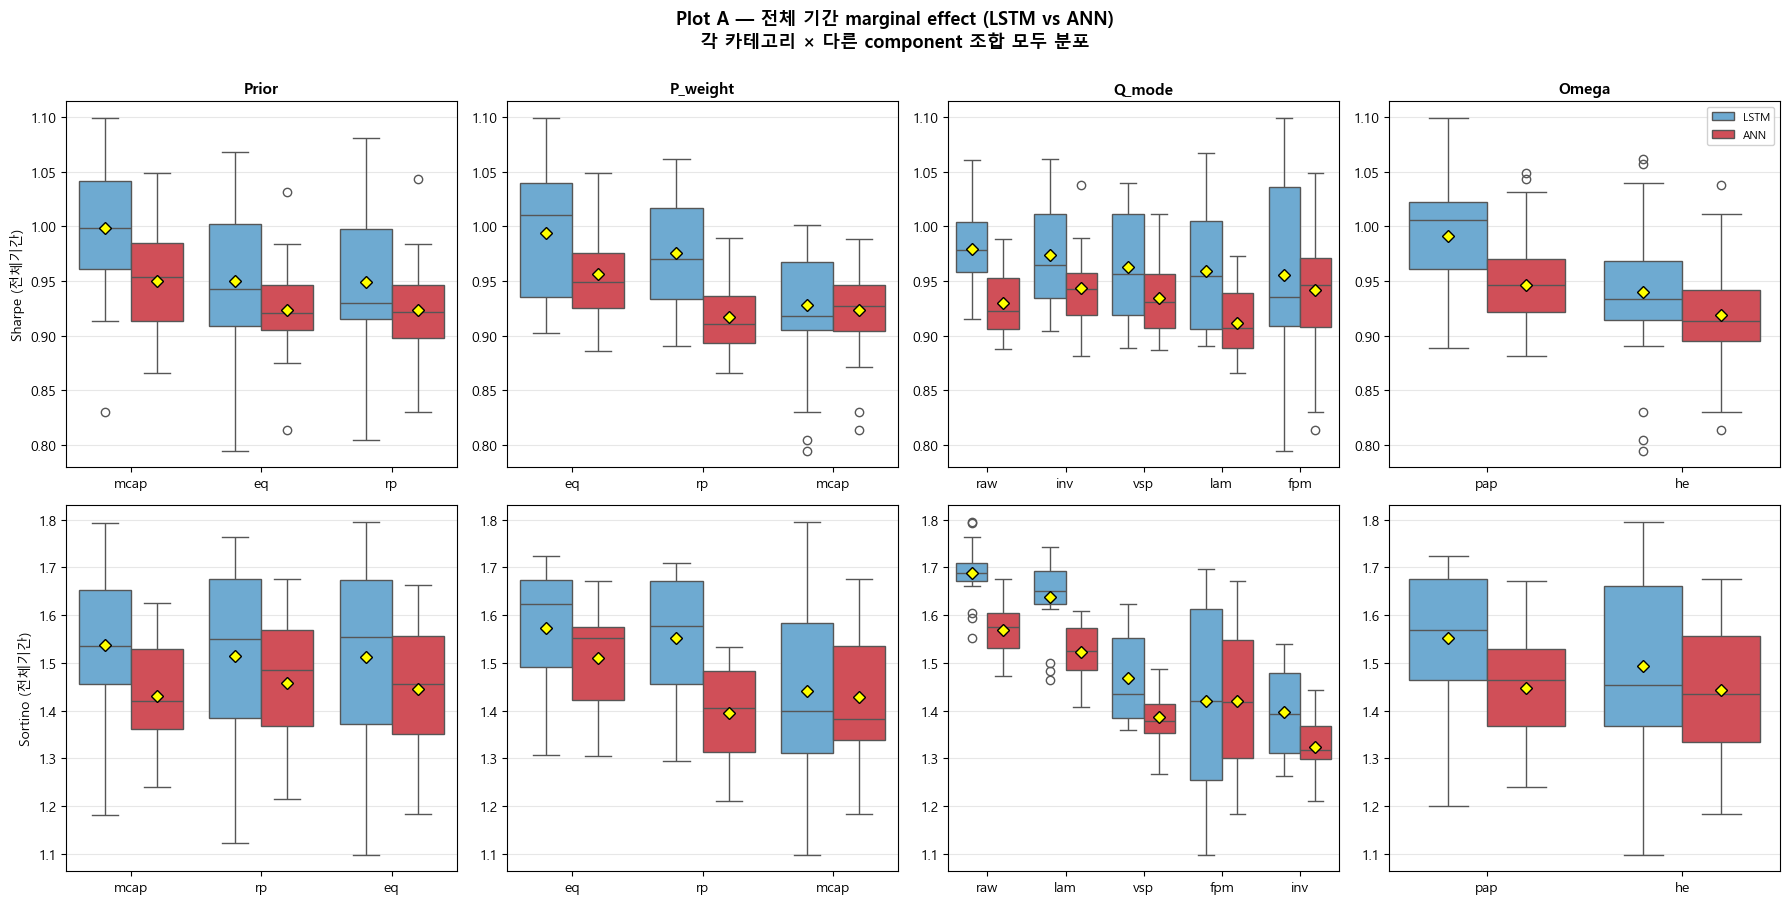


전체 기간 marginal median (LSTM | ANN | Δ)

[Prior]
  Sharpe:
model    ANN   LSTM  Δ(L-A)
    prior                      
    mcap   0.954  0.998   0.045
    eq     0.921  0.943   0.022
    rp     0.922  0.930   0.008
  Sortino:
model    ANN   LSTM  Δ(L-A)
    prior                      
    eq     1.455  1.554   0.099
    rp     1.485  1.549   0.065
    mcap   1.419  1.534   0.115

[P_weight]
  Sharpe:
model    ANN   LSTM  Δ(L-A)
    p_w                        
    eq     0.949  1.010   0.061
    rp     0.911  0.970   0.059
    mcap   0.927  0.918  -0.009
  Sortino:
model    ANN   LSTM  Δ(L-A)
    p_w                        
    eq     1.552  1.623   0.071
    rp     1.404  1.577   0.173
    mcap   1.383  1.399   0.016

[Q_mode]
  Sharpe:
model    ANN   LSTM  Δ(L-A)
    q                          
    raw    0.923  0.979   0.056
    inv    0.943  0.965   0.022
    vsp    0.931  0.957   0.026
    lam    0.907  0.954   0.047
    fpm    0.946  0.935  -0.011
  Sortino:
model    ANN   LSTM  Δ

In [14]:
# ── L_box_A. 전체 기간 marginal effect box plot ──
import seaborn as sns

PRIORS_BP = ['mcap','eq','rp']
PWS_BP    = ['mcap','eq','rp']
QS_BP     = ['lam','raw','inv','vsp','fpm']  # fix 제외
OMEGAS_BP = ['pap','he']

REGIMES_BP = [('전체','2010-01-01','2025-12-31')] + REGIMES  # 전체 + 4 regime


def _box_sh_so(name, s, e):
    if name not in loaded: return np.nan, np.nan
    r = loaded[name]['ret'].dropna()
    r = r[(r.index >= pd.Timestamp(s)) & (r.index <= pd.Timestamp(e)) & (r.index <= pd.Timestamp(CUTOFF))]
    if len(r) < 6: return np.nan, np.nan
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    sh = float(exc.mean()*12/vol) if vol > 0 else np.nan
    dn = r[r<0].std() * np.sqrt(12)
    so = float(exc.mean()*12/dn) if dn and dn > 0 else np.nan
    return sh, so


# Long-format DataFrame (모델 × 90 슬롯)
rows_bp = []
for suffix, model_lbl in [('','LSTM'), ('_ann','ANN')]:
    for prior in PRIORS_BP:
        for pw in PWS_BP:
            for q in QS_BP:
                for omega in OMEGAS_BP:
                    name = f'mat_{prior}_{pw}_{q}_{omega}{suffix}'
                    row = {'prior': prior, 'p_w': pw, 'q': q, 'omega': omega, 'model': model_lbl}
                    for lbl, s, e in REGIMES_BP:
                        sh, so = _box_sh_so(name, s, e)
                        row[f'{lbl}_Sh'] = sh
                        row[f'{lbl}_So'] = so
                    rows_bp.append(row)
mar_df = pd.DataFrame(rows_bp)
print(f'슬롯 수: {len(mar_df)} (모델 × {len(mar_df)//2} 조합)')
print(f'  PRIORS={PRIORS_BP}, PWS={PWS_BP}, QS={QS_BP} (fix 제외), OMEGAS={OMEGAS_BP}')

# ── Plot A: 2 row (Sharpe/Sortino) × 4 col (4 dim) ──
DIMS_BP = [('prior','Prior'),('p_w','P_weight'),('q','Q_mode'),('omega','Omega')]
metrics_A = [('전체_Sh','Sharpe (전체기간)'), ('전체_So','Sortino (전체기간)')]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ri, (metric, mlbl) in enumerate(metrics_A):
    for ci, (dim, dlbl) in enumerate(DIMS_BP):
        ax = axes[ri, ci]
        # 카테고리 정렬: LSTM 평균 기준 내림차순
        order_vals = (mar_df[mar_df['model']=='LSTM']
                      .groupby(dim)[metric].mean()
                      .sort_values(ascending=False).index.tolist())
        sns.boxplot(data=mar_df, x=dim, y=metric, hue='model', ax=ax,
                    order=order_vals,
                    palette={'LSTM':'#5DADE2','ANN':'#E63946'},
                    showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='yellow',
                                   markeredgecolor='black', markersize=6))
        if ri == 0:
            ax.set_title(dlbl, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(mlbl if ci == 0 else '')
        ax.grid(axis='y', alpha=0.3)
        if ri == 0 and ci == 3:
            ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        else:
            ax.legend().set_visible(False)

plt.suptitle('Plot A — 전체 기간 marginal effect (LSTM vs ANN)\n각 카테고리 × 다른 component 조합 모두 분포',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_A_marginal_full.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Summary table — median ──
print()
print('='*80)
print('전체 기간 marginal median (LSTM | ANN | Δ)')
print('='*80)
for dim, dlbl in DIMS_BP:
    print(f'\n[{dlbl}]')
    for metric, mlbl in [('전체_Sh','Sharpe'), ('전체_So','Sortino')]:
        med = mar_df.groupby([dim,'model'])[metric].median().unstack('model')
        med['Δ(L-A)'] = med['LSTM'] - med['ANN']
        order = med['LSTM'].sort_values(ascending=False).index
        med = med.loc[order].round(3)
        print(f'  {mlbl}:')
        print(med.to_string().replace('\n', '\n    '))


## L_box_B. Regime × Dim marginal effect — Sharpe & Sortino

Plot A 와 동일한 4 dim × LSTM/ANN box plot 을 **4 regime 별로 분리**.

→ R1/R2/R3/R4 각각에서 어느 카테고리가 단독 우위인지 분포 수준 확인.
→ 개별 슬롯 micro 해석 (e.g. "R2 의 mat_mcap_rp_lam_pap 가 왜 짐") 우회.

Sharpe 와 Sortino 각각 4×4 figure.


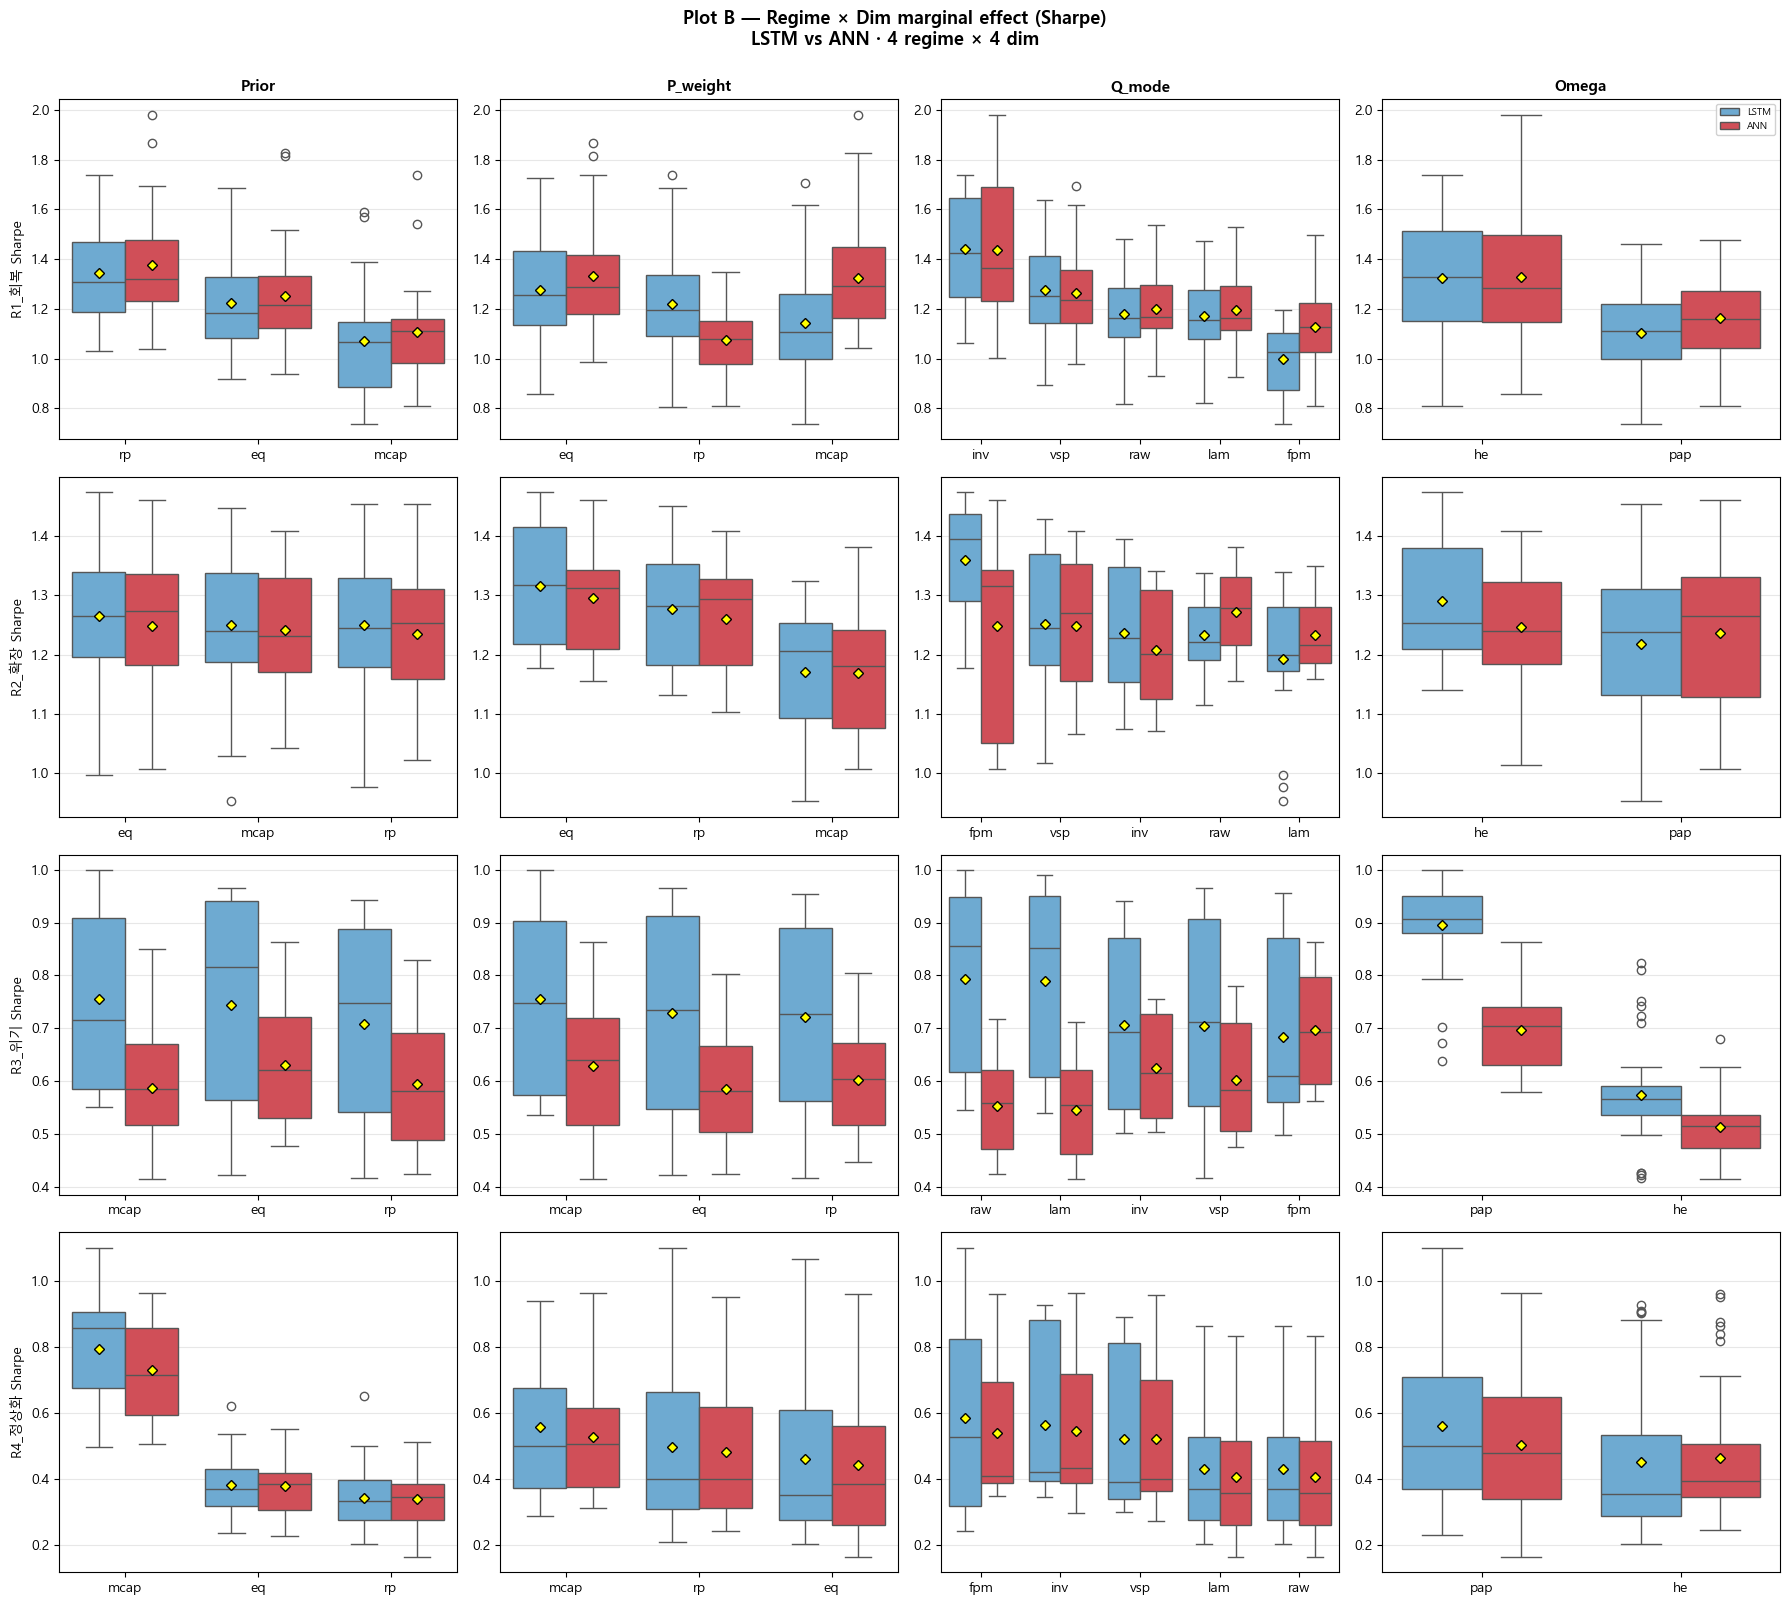

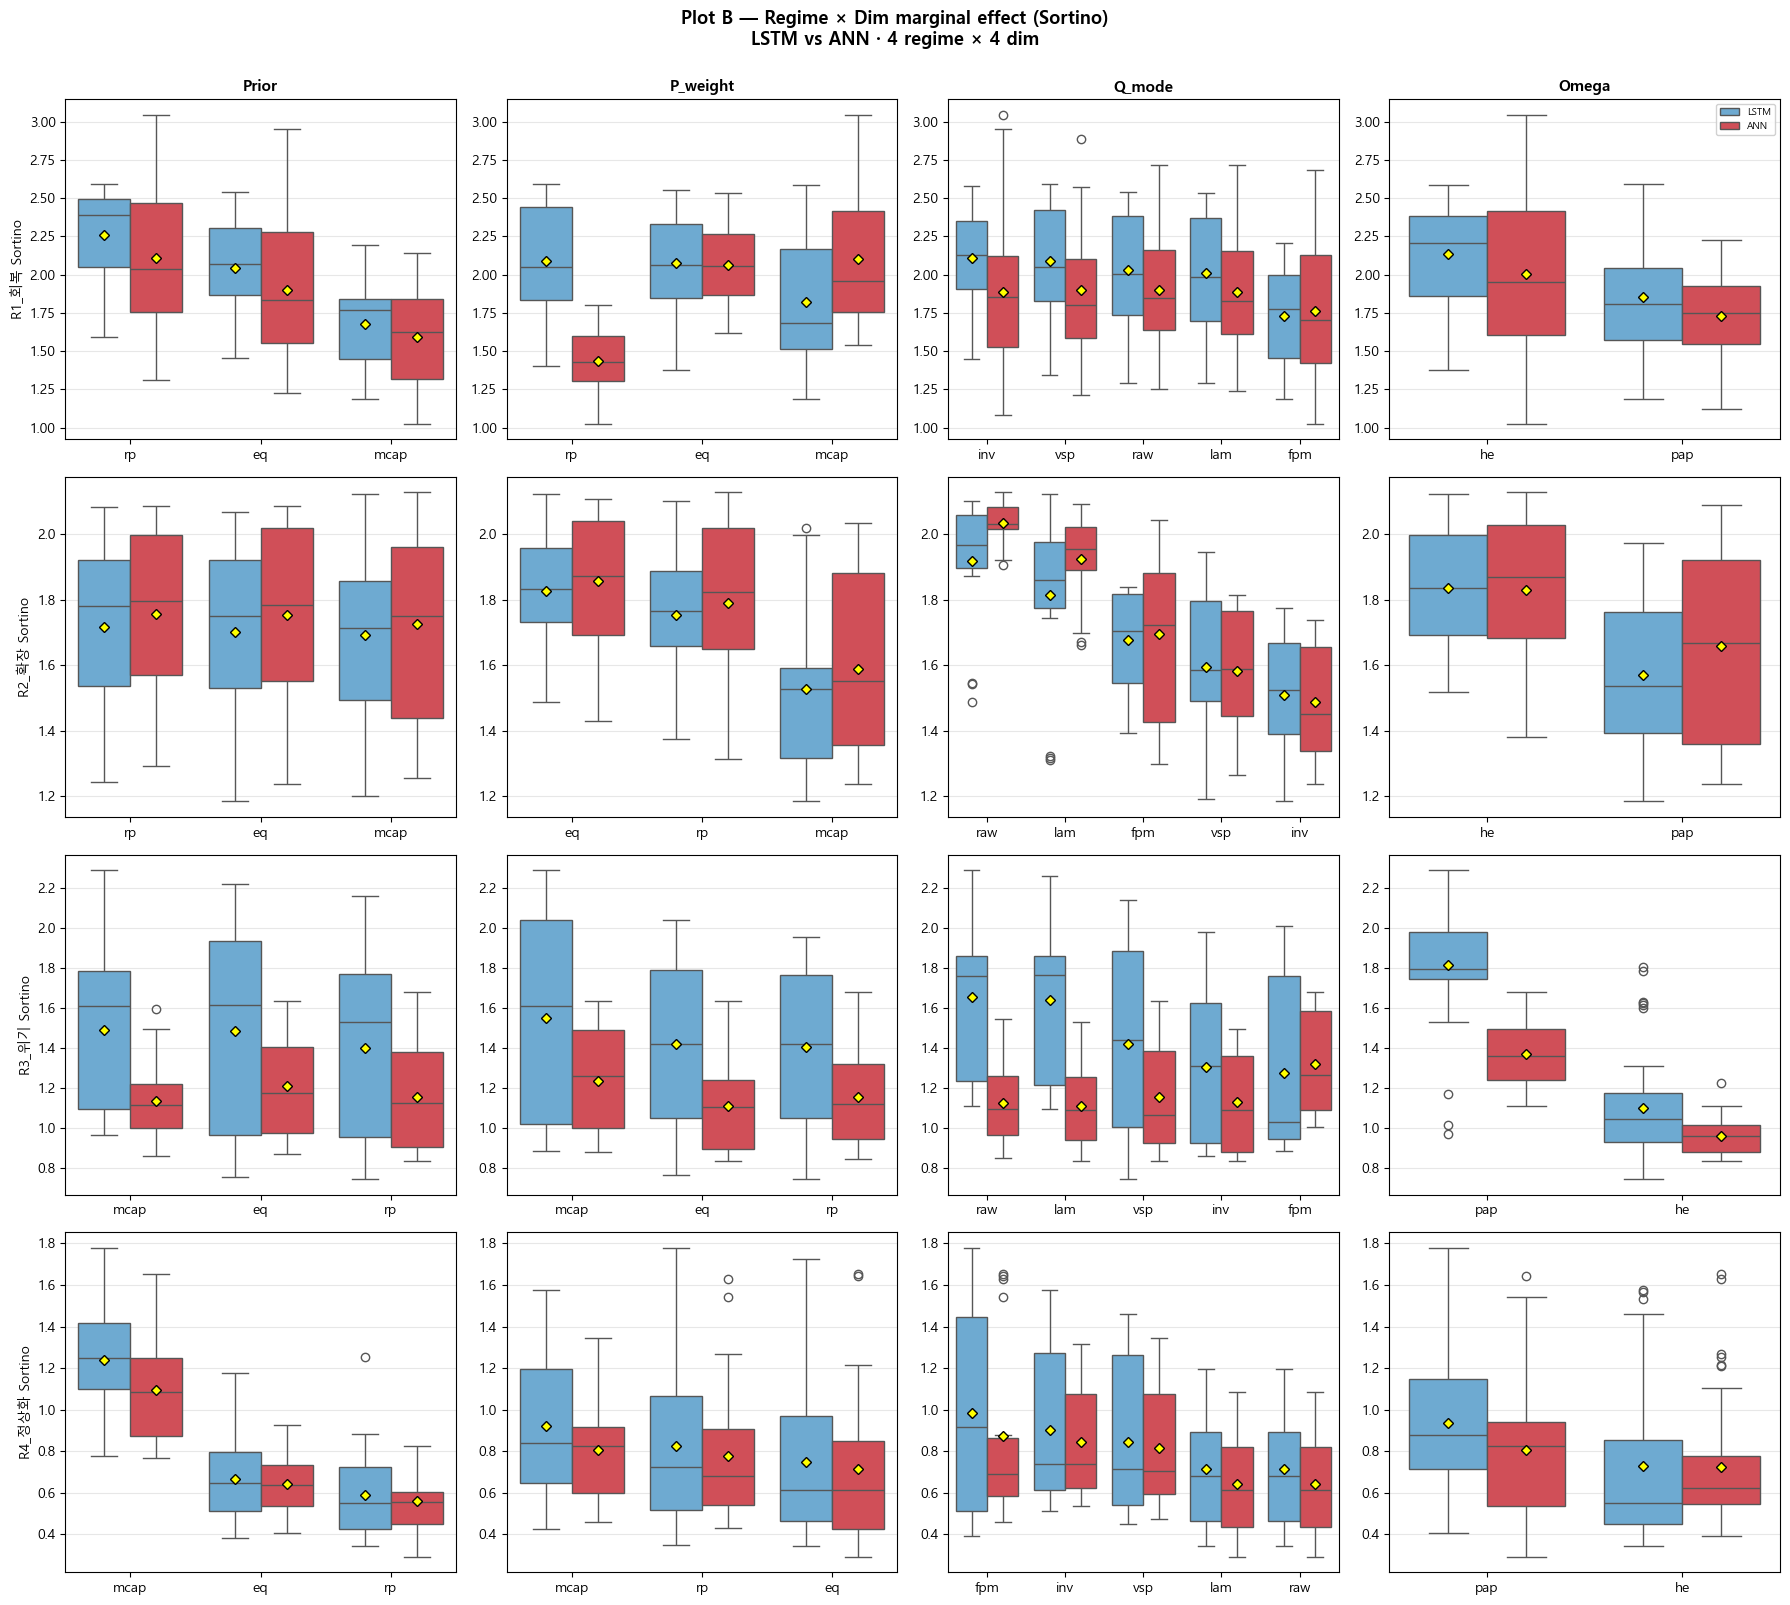


Regime × Dim marginal median (LSTM | ANN | Δ)

[Prior]
  R1_회복 Sharpe : rp: L=+1.306/A=+1.321/Δ=-0.015  eq: L=+1.182/A=+1.217/Δ=-0.035  mcap: L=+1.068/A=+1.113/Δ=-0.044
  R2_확장 Sharpe : eq: L=+1.266/A=+1.274/Δ=-0.009  rp: L=+1.246/A=+1.253/Δ=-0.007  mcap: L=+1.240/A=+1.232/Δ=+0.008
  R3_위기 Sharpe : eq: L=+0.817/A=+0.622/Δ=+0.195  rp: L=+0.747/A=+0.581/Δ=+0.166  mcap: L=+0.716/A=+0.585/Δ=+0.130
  R4_정상화 Sharpe : mcap: L=+0.857/A=+0.716/Δ=+0.141  eq: L=+0.371/A=+0.387/Δ=-0.016  rp: L=+0.332/A=+0.347/Δ=-0.014

[P_weight]
  R1_회복 Sharpe : eq: L=+1.254/A=+1.288/Δ=-0.035  rp: L=+1.196/A=+1.079/Δ=+0.117  mcap: L=+1.108/A=+1.292/Δ=-0.184
  R2_확장 Sharpe : eq: L=+1.318/A=+1.312/Δ=+0.006  rp: L=+1.283/A=+1.293/Δ=-0.010  mcap: L=+1.207/A=+1.181/Δ=+0.026
  R3_위기 Sharpe : mcap: L=+0.747/A=+0.640/Δ=+0.107  eq: L=+0.734/A=+0.582/Δ=+0.152  rp: L=+0.727/A=+0.605/Δ=+0.123
  R4_정상화 Sharpe : mcap: L=+0.502/A=+0.505/Δ=-0.003  rp: L=+0.399/A=+0.400/Δ=-0.000  eq: L=+0.352/A=+0.384/Δ=-0.032

[Q_mode]
  R1_회복 

In [15]:
# ── L_box_B. Regime × Dim marginal effect ──
REGIMES_PLOT = REGIMES  # R1/R2/R3/R4 (전체 제외)

for metric_kind, metric_suffix, metric_label in [('Sharpe','Sh','Sharpe'), ('Sortino','So','Sortino')]:
    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    for ri, (rlbl, _, _) in enumerate(REGIMES_PLOT):
        col = f'{rlbl}_{metric_suffix}'
        for ci, (dim, dlbl) in enumerate(DIMS_BP):
            ax = axes[ri, ci]
            order_vals = (mar_df[mar_df['model']=='LSTM']
                          .groupby(dim)[col].mean()
                          .sort_values(ascending=False).index.tolist())
            sns.boxplot(data=mar_df, x=dim, y=col, hue='model', ax=ax,
                        order=order_vals,
                        palette={'LSTM':'#5DADE2','ANN':'#E63946'},
                        showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='yellow',
                                       markeredgecolor='black', markersize=5))
            if ri == 0:
                ax.set_title(dlbl, fontsize=11, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel(f'{rlbl} {metric_label}' if ci == 0 else '')
            ax.grid(axis='y', alpha=0.3)
            if ri == 0 and ci == 3:
                ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
            else:
                ax.legend().set_visible(False)
    plt.suptitle(f'Plot B — Regime × Dim marginal effect ({metric_label})\nLSTM vs ANN · 4 regime × 4 dim',
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'plot_B_marginal_regime_{metric_kind.lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()

# ── Regime × Dim median summary ──
print()
print('='*100)
print('Regime × Dim marginal median (LSTM | ANN | Δ)')
print('='*100)
for dim, dlbl in DIMS_BP:
    print(f'\n[{dlbl}]')
    for rlbl, _, _ in REGIMES_PLOT:
        sh_col = f'{rlbl}_Sh'
        med = mar_df.groupby([dim,'model'])[sh_col].median().unstack('model')
        med['Δ(L-A)'] = med['LSTM'] - med['ANN']
        order = med['LSTM'].sort_values(ascending=False).index
        med = med.loc[order]
        cats_str = '  '.join(f'{cat}: L={r["LSTM"]:+.3f}/A={r["ANN"]:+.3f}/Δ={r["Δ(L-A)"]:+.3f}'
                              for cat, r in med.iterrows())
        print(f'  {rlbl} Sharpe : {cats_str}')
